In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product, visualize_policy_suspension_impact
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price, show_two_panel_conversion_by_brand_price
from etl.price import visualize_conversion_by_equipment_type_brand_price, show_conversion_by_price_dashboard, show_product_type_price_conversion_heatmap
from etl.season import visualize_conversion_by_season, visualize_regional_seasonality
from etl.period import visualize_conversion_by_year, report_best_and_worst_months, show_conversion_by_price_over_time, overlay_all_years_on_one_plot
from etl.period import visualize_conversion_by_prices_sweet_spot_shift, visualize_decision_times, show_decision_time_dashboard
from etl.product import visualise_heat_pump_performance, show_product_type_by_brand_heatmap, show_product_type_by_agency_heatmap, show_brand_by_product_type_heatmap


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 37,008 quotes from 25,716 customers


In [2]:
#customers = aggregate_customer(df_clean)

In [ ]:
all_customers = pd.read_csv('customer_master_data.csv')

In [4]:

# Using quarter column (if you have it)
customers_2025_q4 = all_customers[
    (all_customers['year'] == 2025) & 
    (all_customers['quarter'] == 4)
]

# Using date range
customers_2025_q4 = all_customers[
    (all_customers['first_quote_date'] >= '2025-10-01') & 
    (all_customers['first_quote_date'] <= '2025-12-31')
]

print(f"Q4 2025 customers: {len(customers_2025_q4):,}")

Q4 2025 customers: 2,872


In [5]:
customers = customers_2025_q4


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.333853            1923            642.0
True                      0.419389             949            398.0

Chi-square p-value: 8.790733e-06
Statistically significant: YES

Conversion without issues: 33.39%
Conversion with issues: 41.94%
Difference: 8.6 percentage points
Customer-level finding: +8.6 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.35
  With issues: 1.53
  Ratio: 1.13x

avg_quote_amount:
  No issues: 5644.64
  With issues: 10317.63
  Ratio: 1.83x

max_quote_amount:
  No issues: 5992.35
  With issues: 11087.40
  Ratio: 1.85x

customer_duration_days:
  No issues: 4.21
  With issues: 7.05
  Ratio: 1.67x

price_range:
  No issues: 767.85
  With issues: 1454.56
  Ratio: 1.89x

multiple_quotes:
  No issues: 0.2

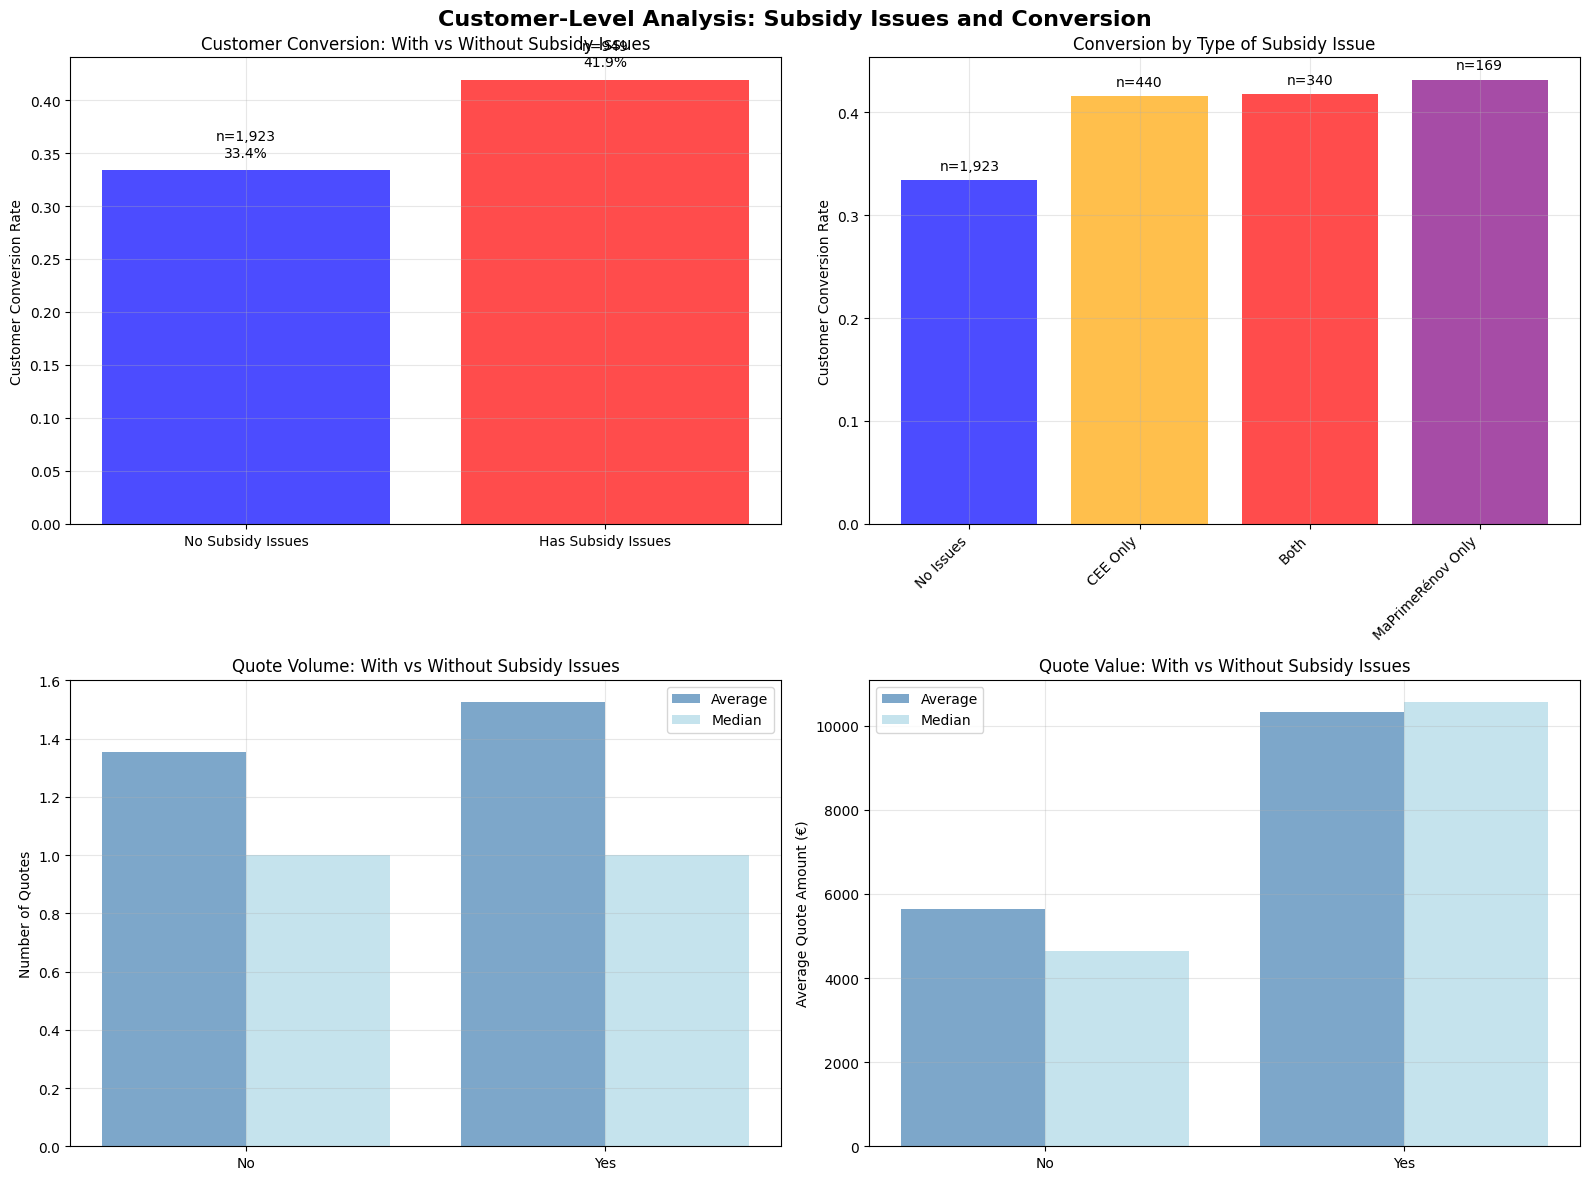


Policy Suspension Impact

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263
Unique values in during_suspension: [False]

⚠️  Only data during normal periods available

Conversion during subsidy suspensions:
                    mean  count
Normal Periods  0.359336   2769


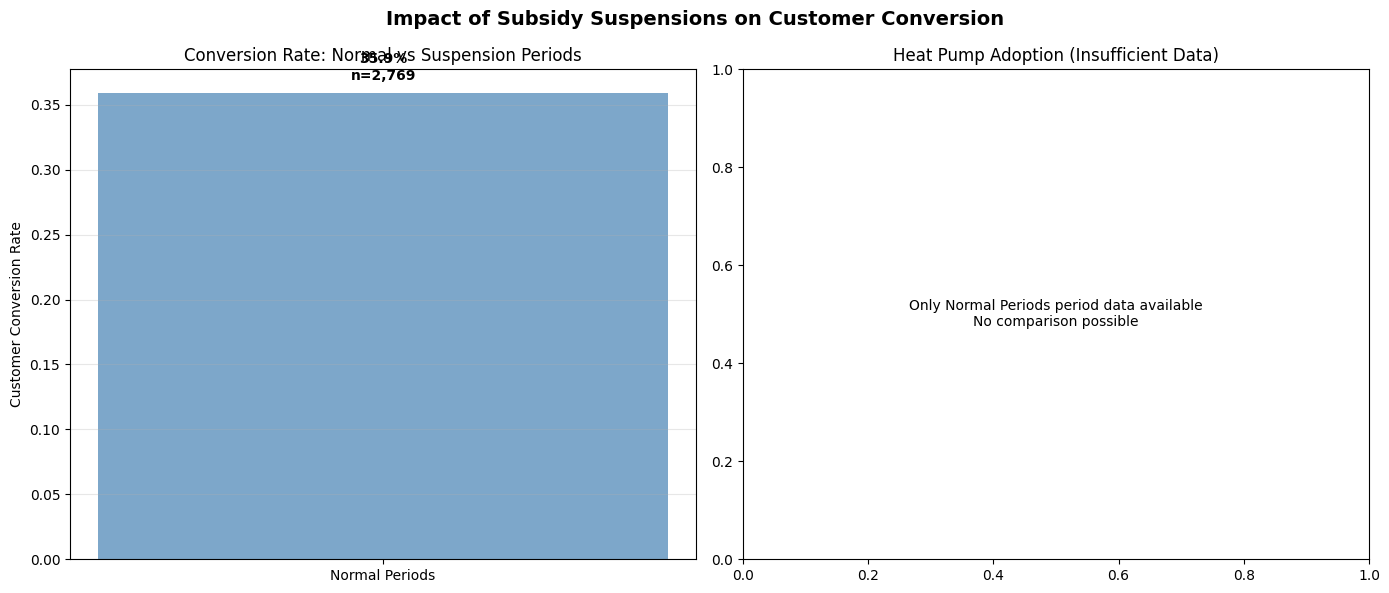

Unique values in main_product_family:
main_product_family
Chaudière                           926
Poêle                               607
Pompe à chaleur                     523
Climatisation                       495
ECS : Chauffe-eau ou adoucisseur    154
Appareil hybride                     52
Photovoltaïque                       34
Autres                               30
Emetteur de chauffage  ou chappe     25
Produit VMC                          12
Unknown                               9
Accessoire de pose                    4
Plomberie Sanitaire                   1
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           926
Poêle                               607
Pompe à chaleur                     523
Climatisation                       495
ECS : Chauffe-eau ou adoucisseur    154
Appareil hybride                     52
Photovoltaïque                       34
Autres                               30
Emetteur de chauffage  ou chappe     25
P

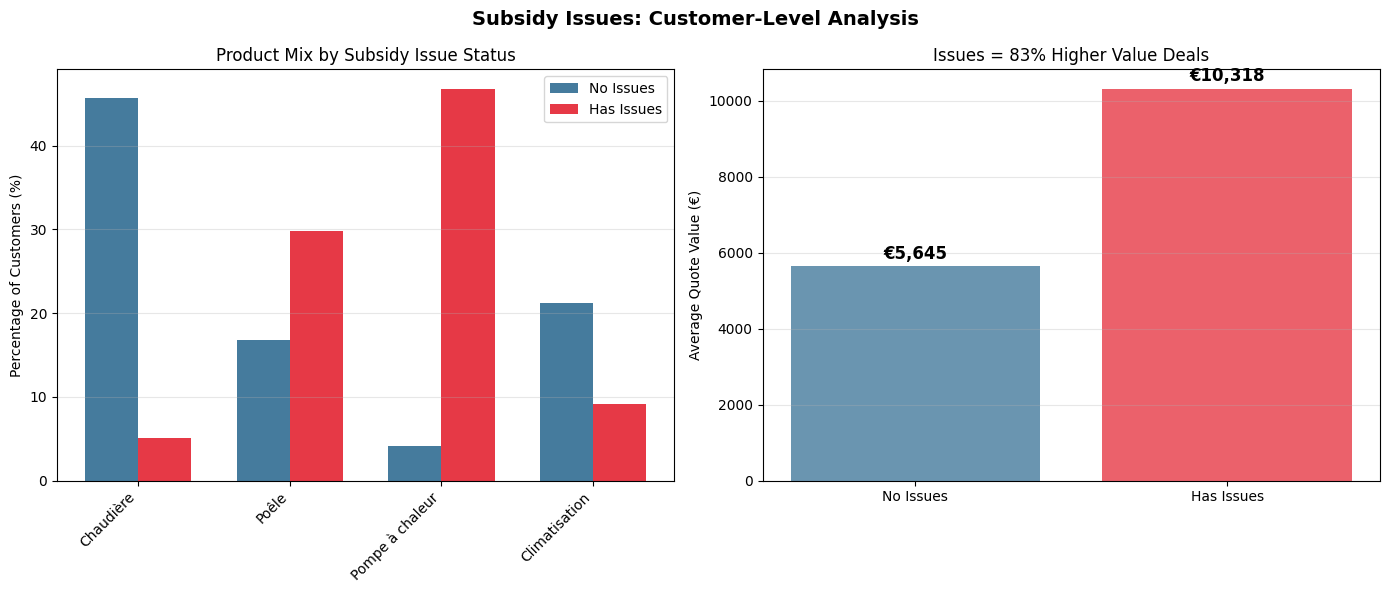


Threshold effect

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263


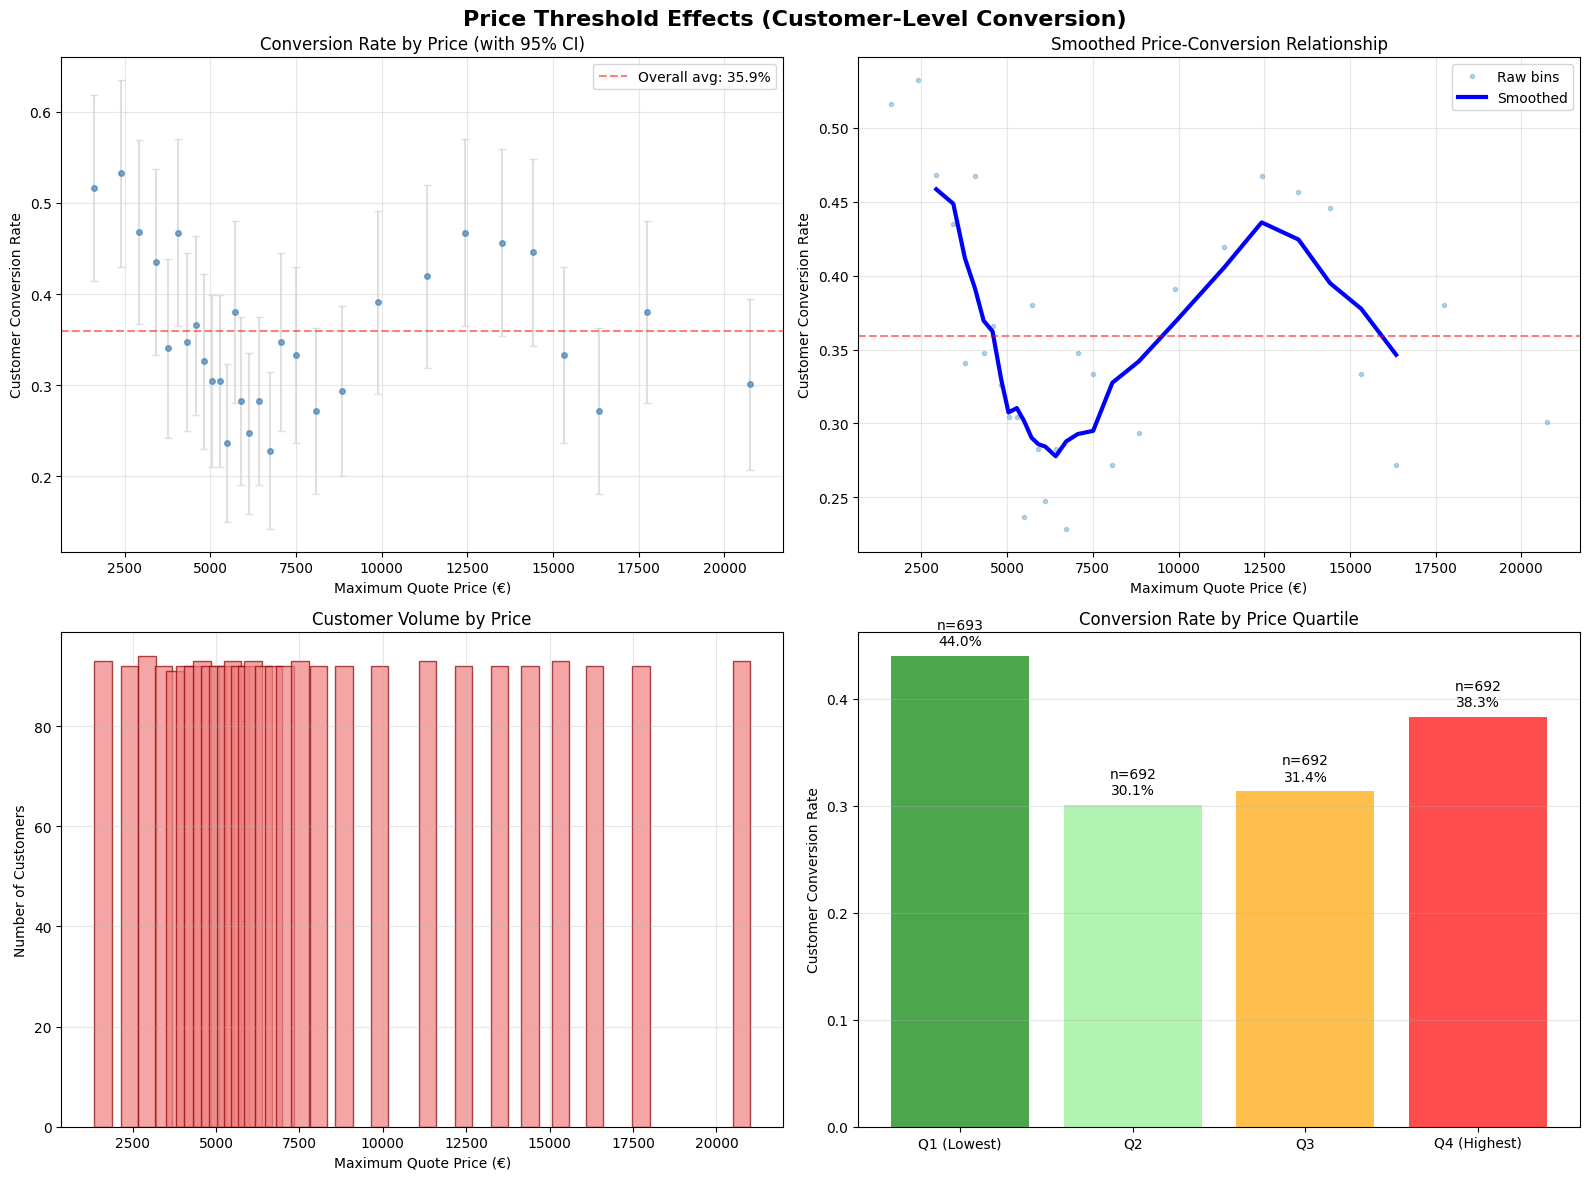


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 44.0% (n=693)
  Q2: 30.1% (n=692)
  Q3: 31.4% (n=692)
  Q4 (Highest): 38.3% (n=692)

Difference between lowest and highest quartile: 5.7 percentage points

Sweet spots (above-average conversion):
  €1,611: 51.6% (n=93)
  €2,410: 53.3% (n=92)
  €2,935: 46.8% (n=94)
  €3,431: 43.5% (n=92)
  €4,065: 46.7% (n=92)
  €4,575: 36.6% (n=93)
  €5,715: 38.0% (n=92)
  €9,905: 39.1% (n=92)
  €11,336: 41.9% (n=93)
  €12,425: 46.7% (n=92)
  €13,500: 45.6% (n=92)
  €14,421: 44.6% (n=92)
  €17,733: 38.0% (n=92)

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
price_quartile                                                
Q1_Low                   21.2    44.6        0.1   24.6    9.5
Q2_MidLow                14.6    39.6        0.4    2.4   43.0
Q3_MidHigh     

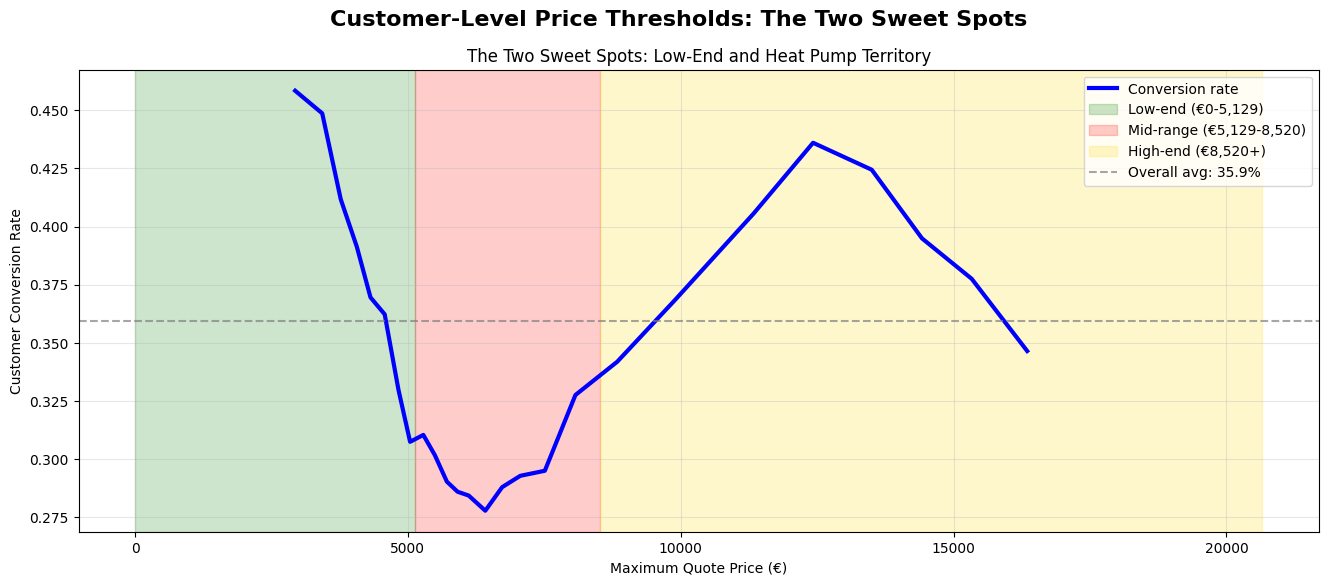

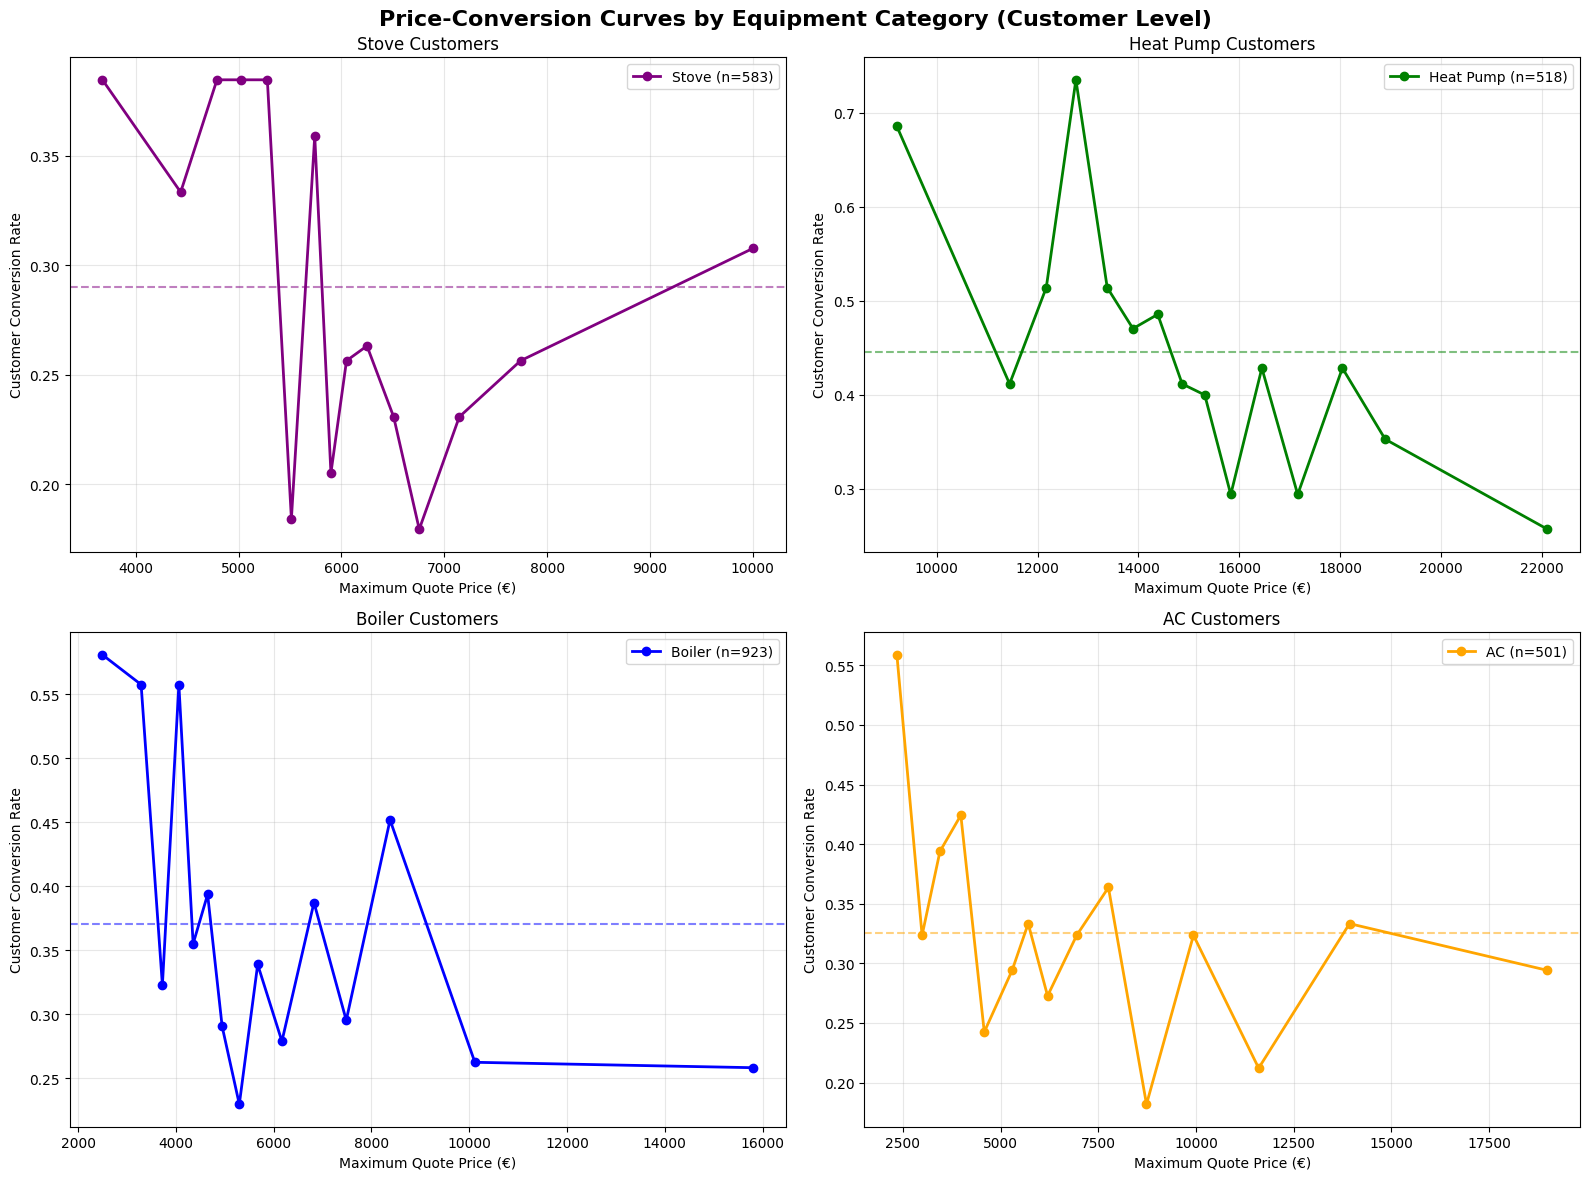


Conversion by Brand Price

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'SAUNIER DUVAL', 'MCZ', 'E.L.M. LEBLANC', 'DE DIETRICH', 'FRISQUET', 'Edilkamin']


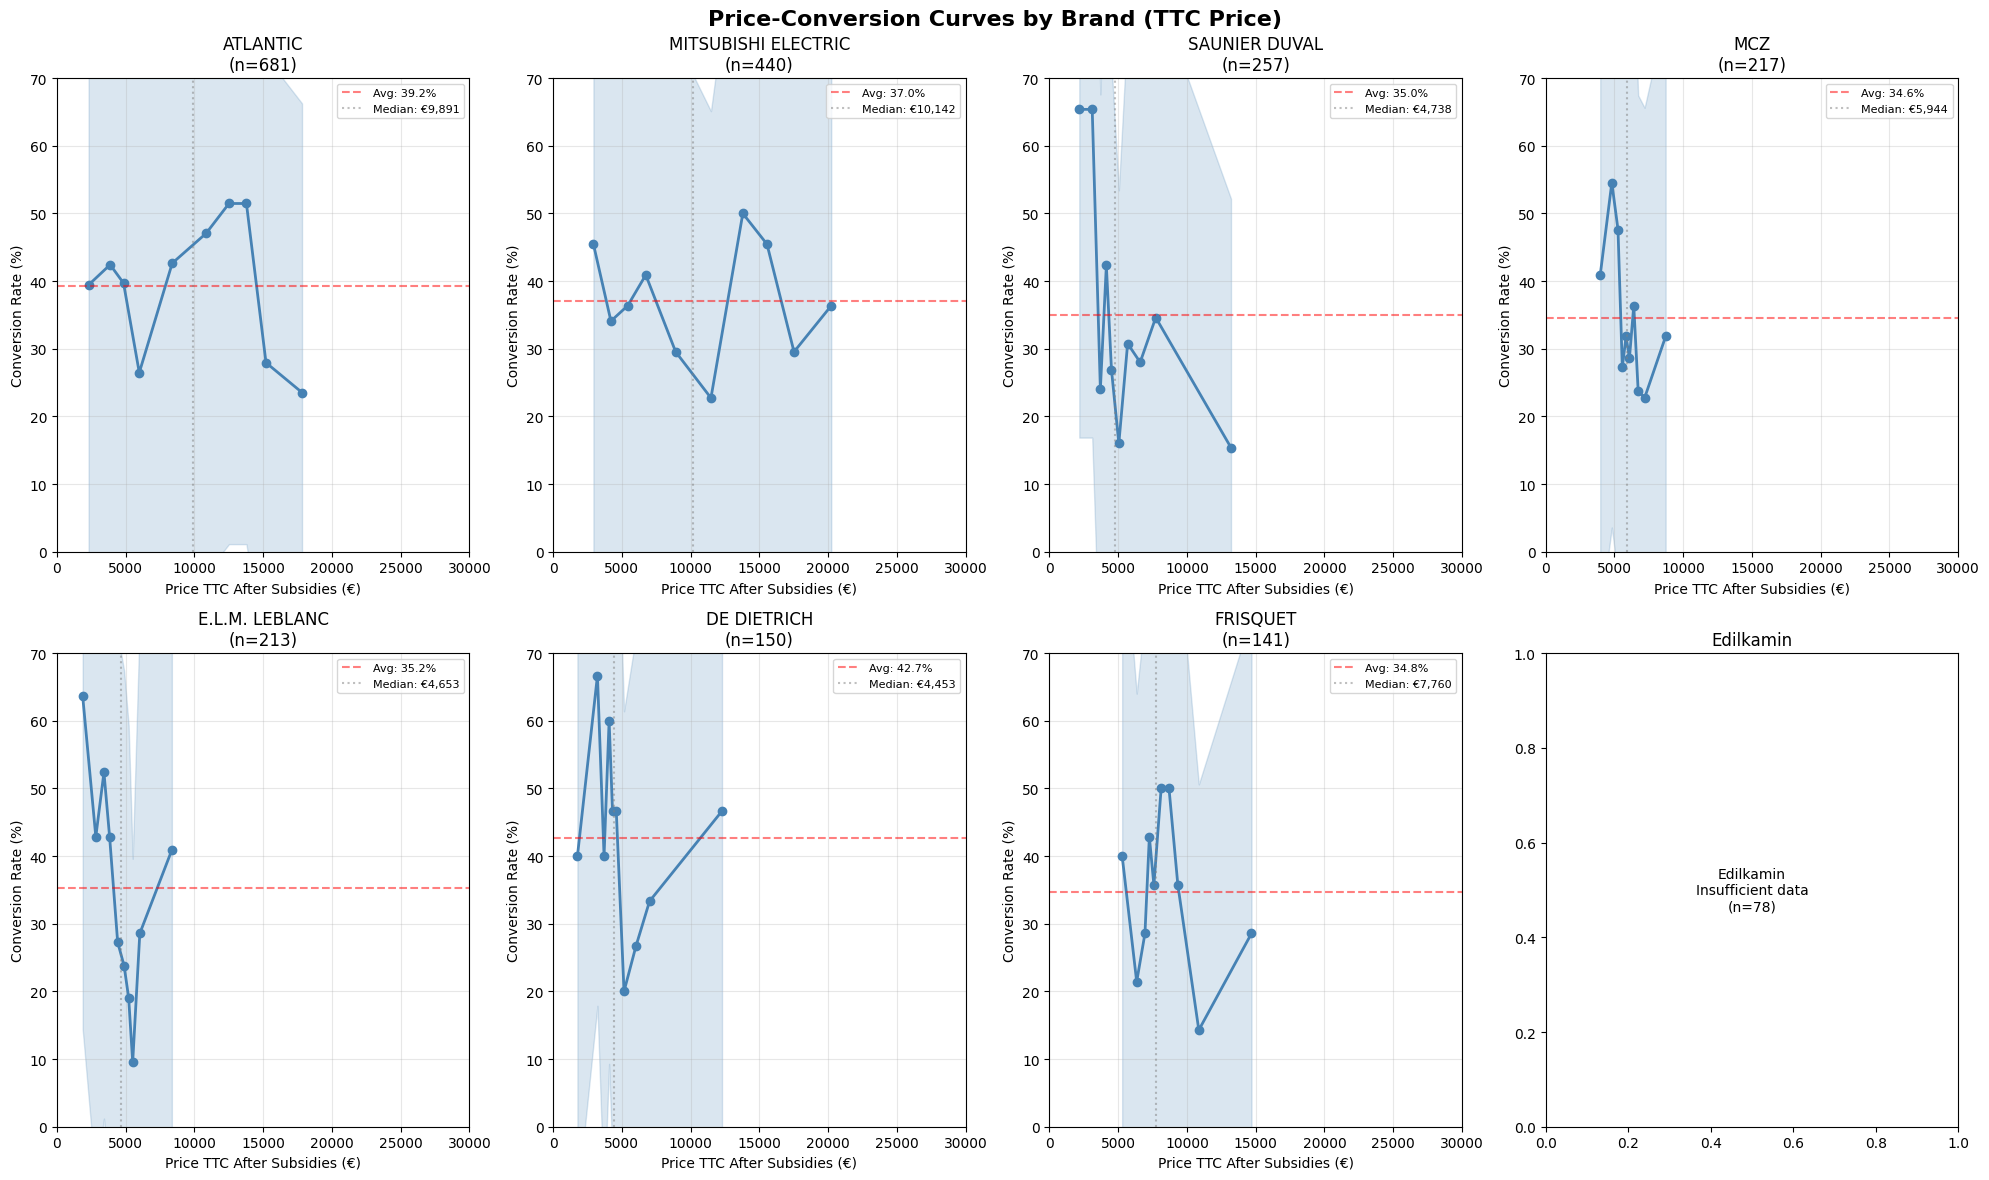


Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263


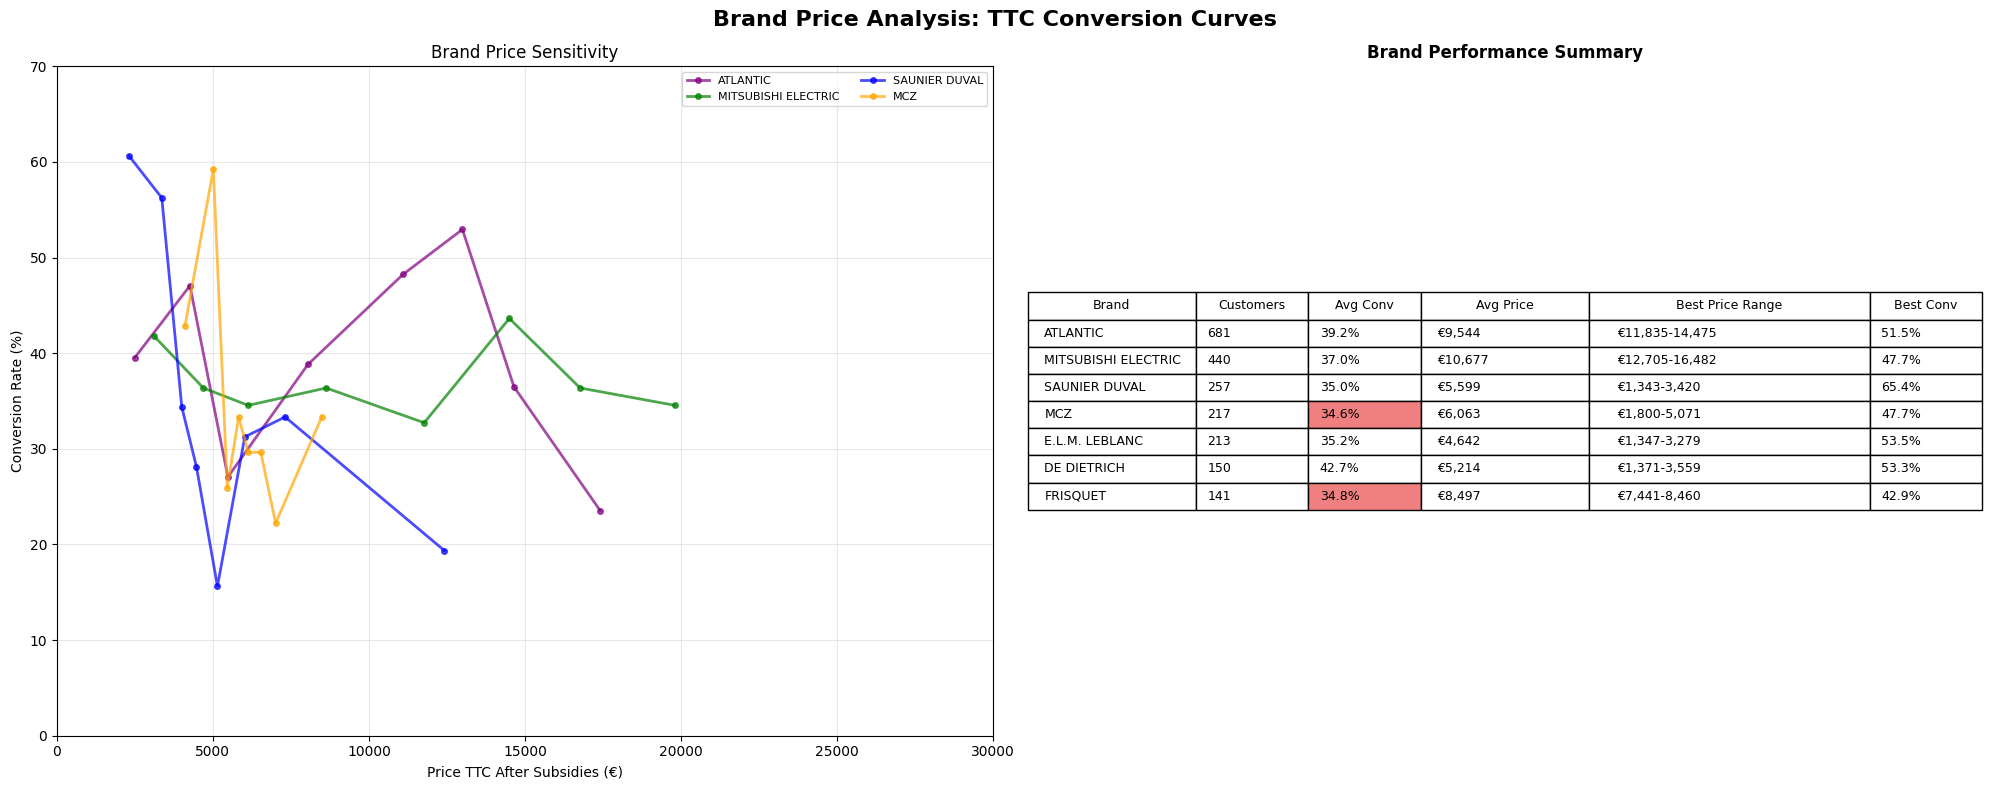


TTC Price-conversion curves: 4 equipment types, multiple brands per graph

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

Heat Pump - Top brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC']

Boiler - Top brands: ['SAUNIER DUVAL', 'E.L.M. LEBLANC', 'ATLANTIC', 'FRISQUET', 'DE DIETRICH']

Stove - Top brands: ['MCZ', 'Edilkamin', 'JOLLY MEC', 'PALAZZETTI', 'ORANIER', 'DOVRE']

AC - Top brands: ['MITSUBISHI ELECTRIC', 'ATLANTIC']


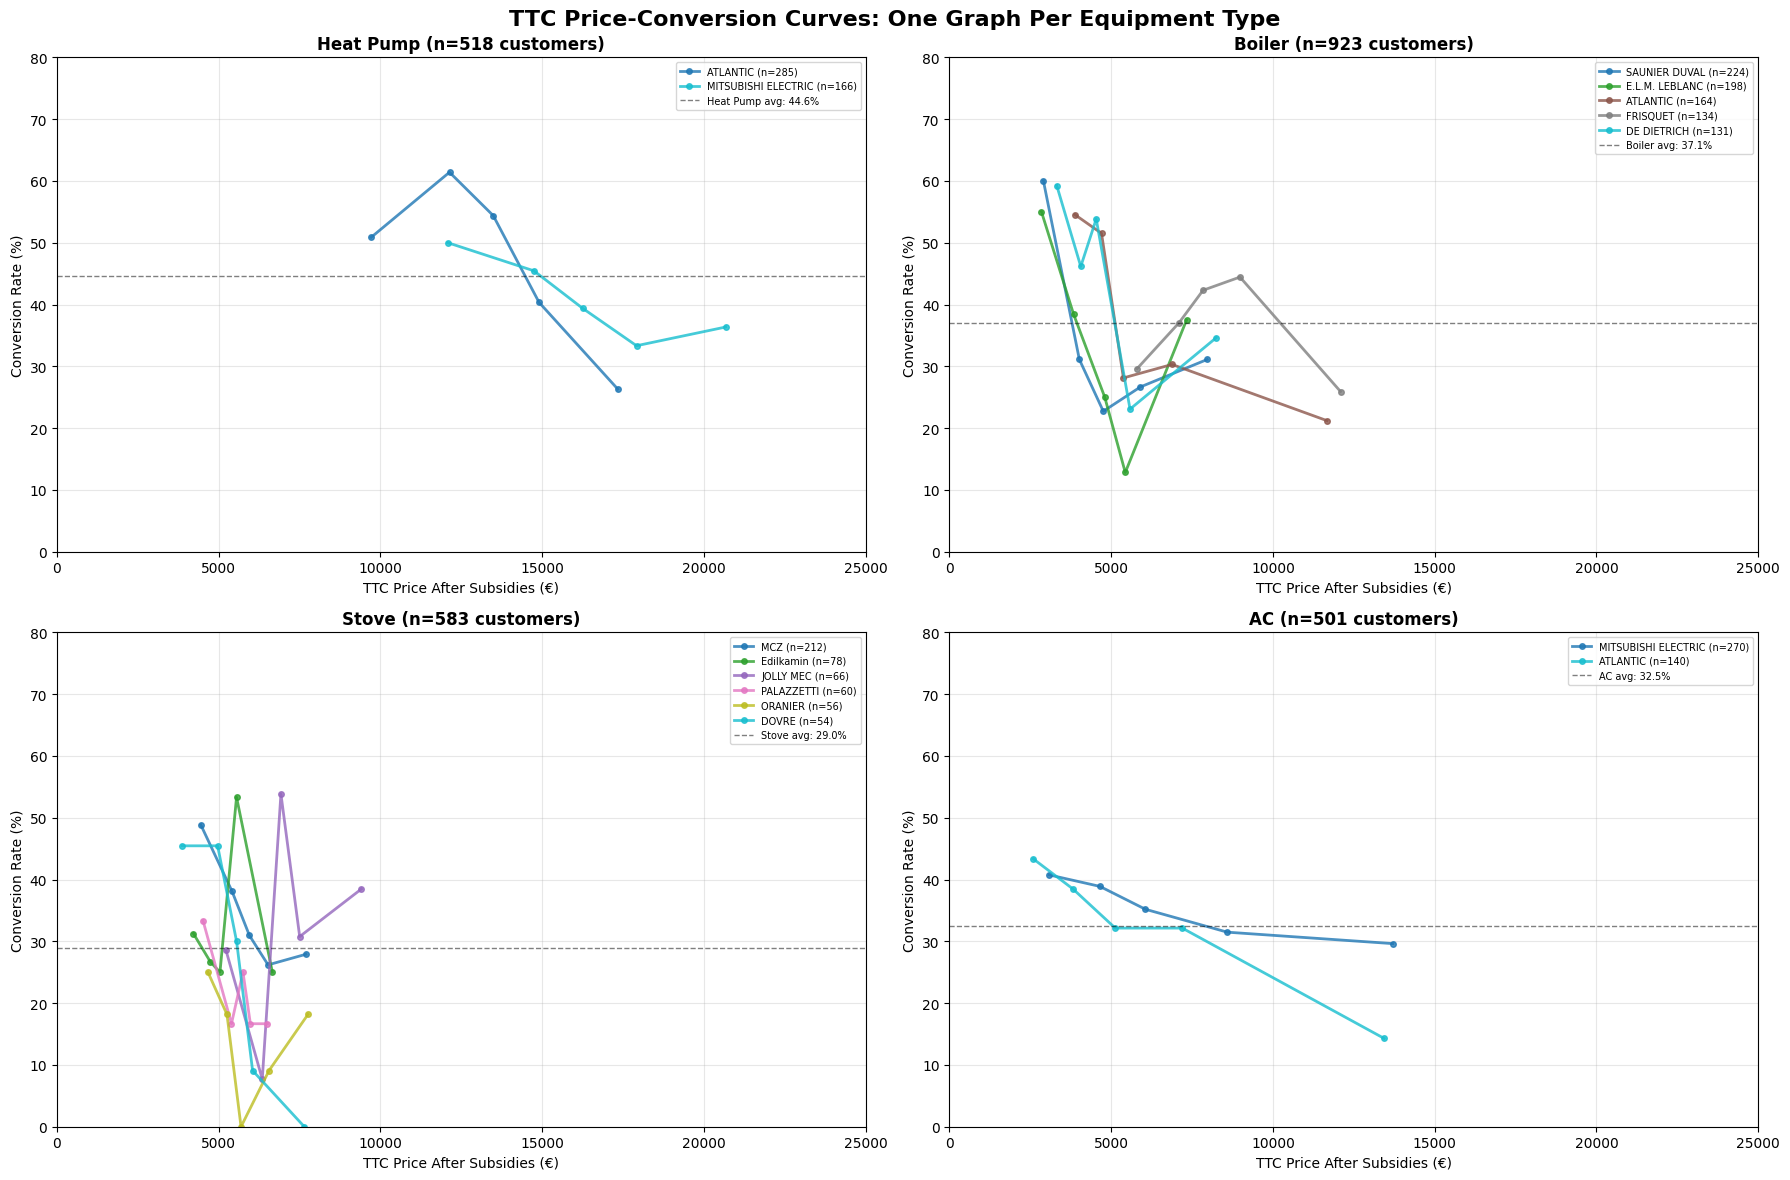


Seasonal Effects on Customer Conversion


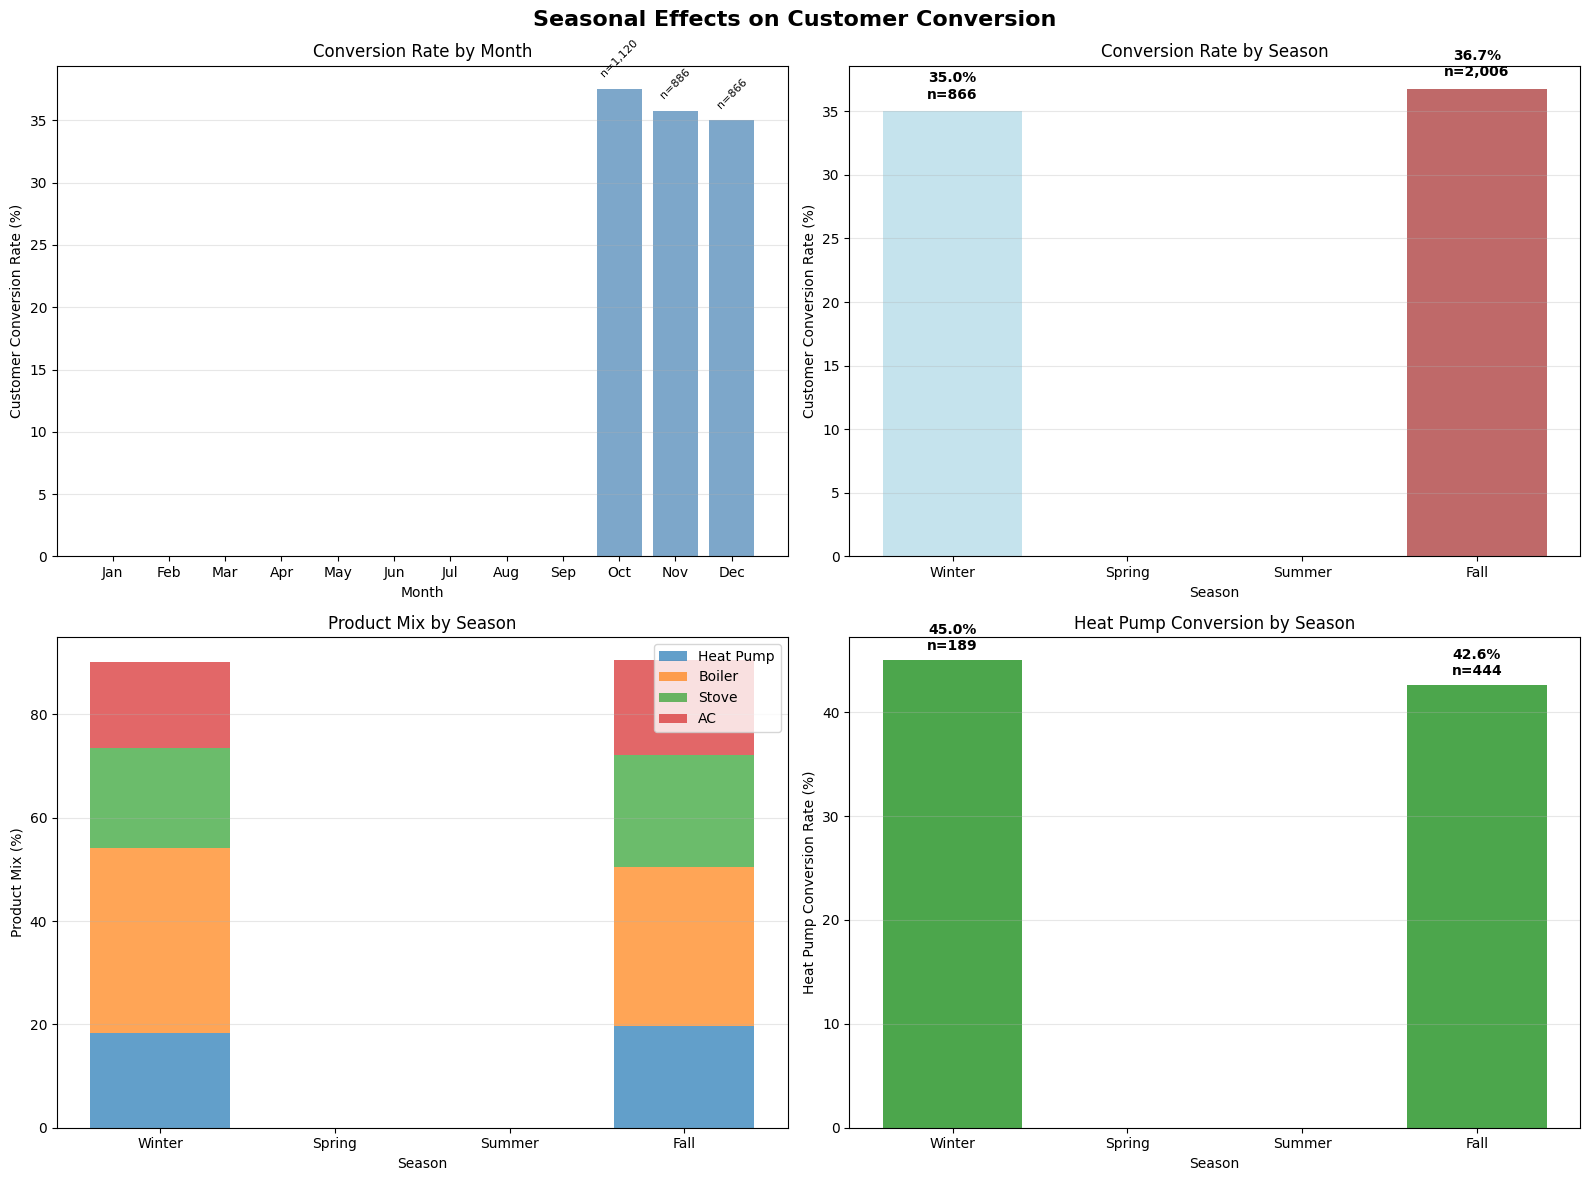


SEASONAL STATISTICS

Conversion by season:
  Winter: 35.0% (n=866)
  Fall: 36.7% (n=2,006)

Seasonality chi-square p-value: 0.3932
Statistically significant: NO

Regional Seasonal Pattern

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

Top regions: ['Auvergne-Rhône-Alpes', 'Normandie', 'Hauts-de-France']


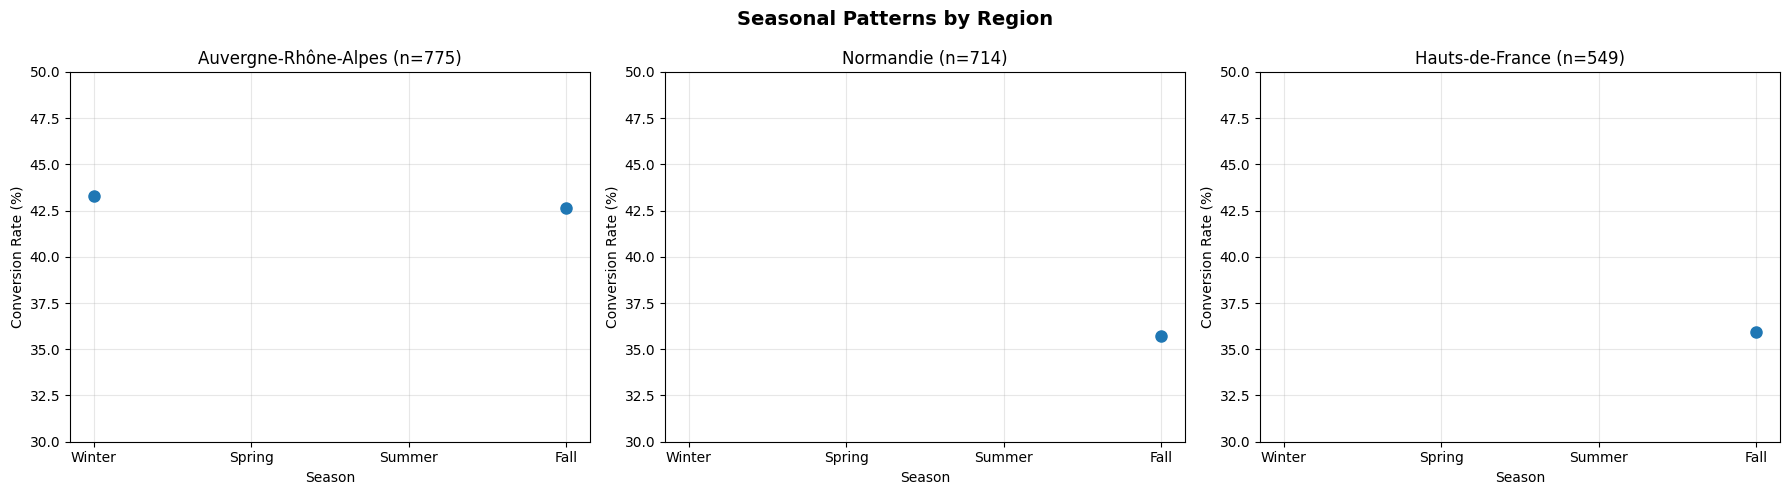


Year-over-year trends

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

Quarterly conversion rates:
                  mean  count
year_quarter                 
2025Q4        0.359336   2769


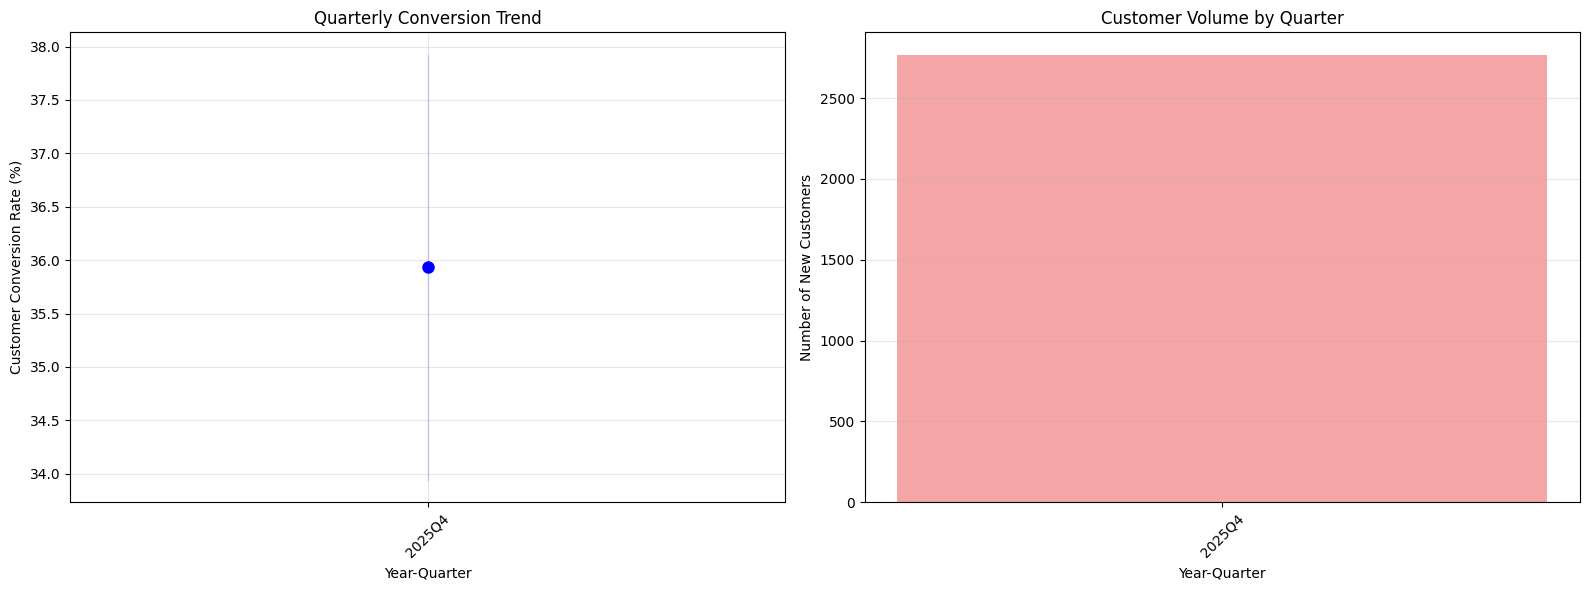


Best and Worst Months Report

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

⚠️  Only one suspension period found: [False]
Skipping suspension comparison

Best month: 10 (37.6%, n=1080)

Best season: Fall (36.5%)
Worst season: Winter (34.6%)

Heat pump conversion by season:
  Winter: 44.9%
  Fall: 43.8%

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263


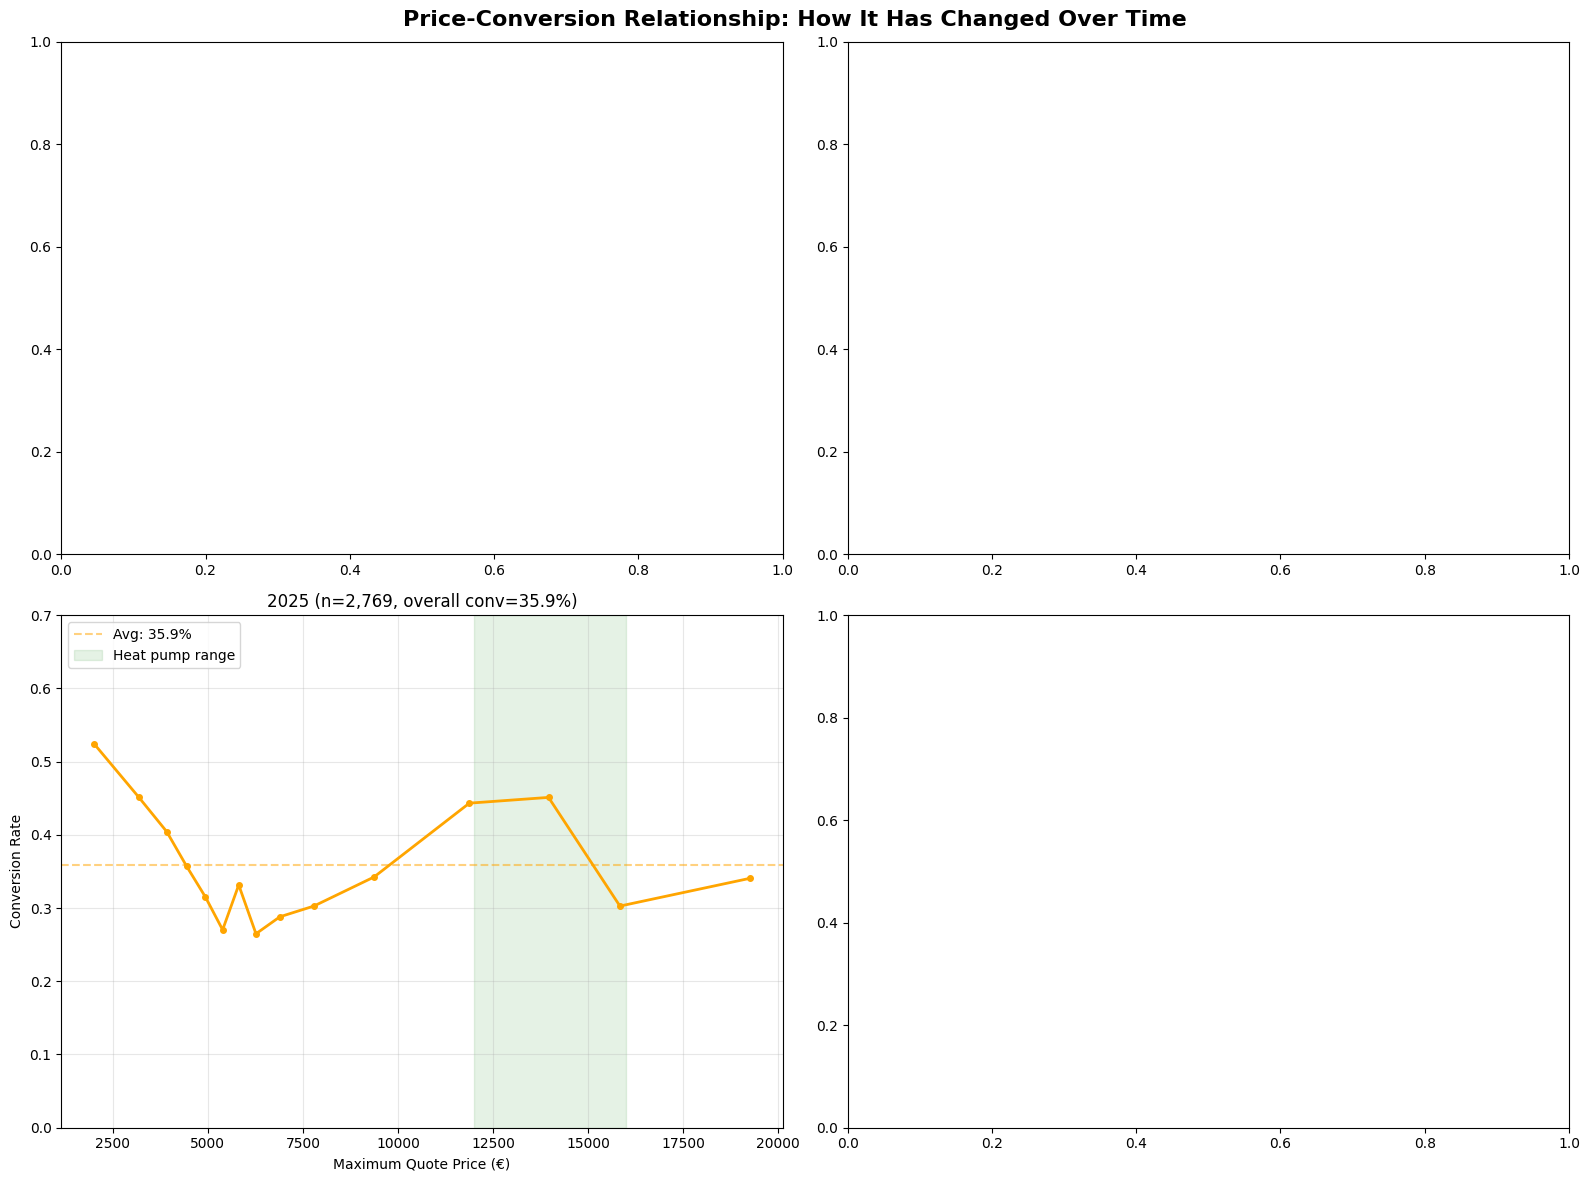


Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263


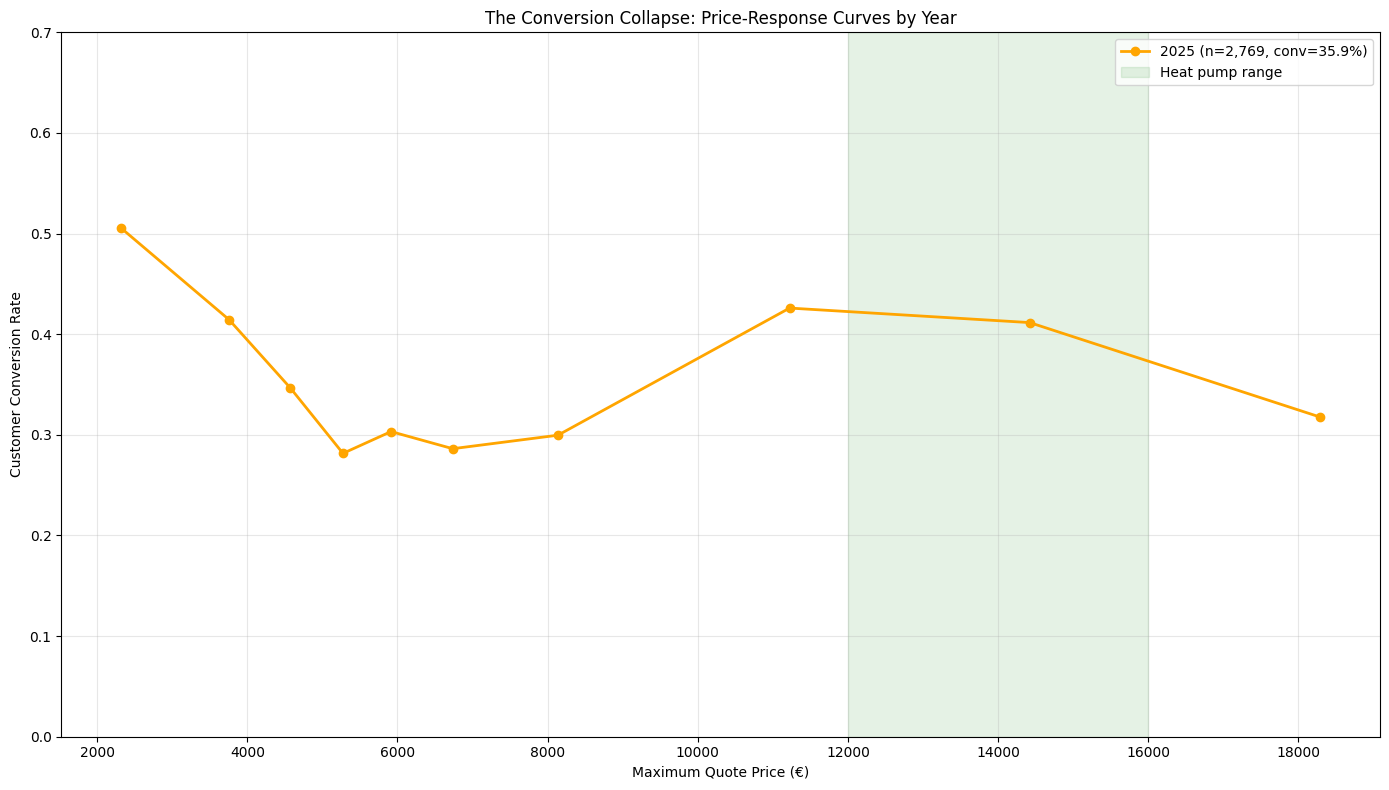


Sweet Spot Analysis Over Time

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

Sweet spots by year (price points with conversion > avg + 3%):

2025 (overall avg: 35.9%):
  €1,825: 53.2% (n=139)
  €2,812: 47.9% (n=140)
  €3,516: 39.4% (n=137)
  €3,993: 43.5% (n=138)
  €10,273: 39.6% (n=139)
  €12,179: 45.7% (n=138)
  €13,721: 44.9% (n=138)


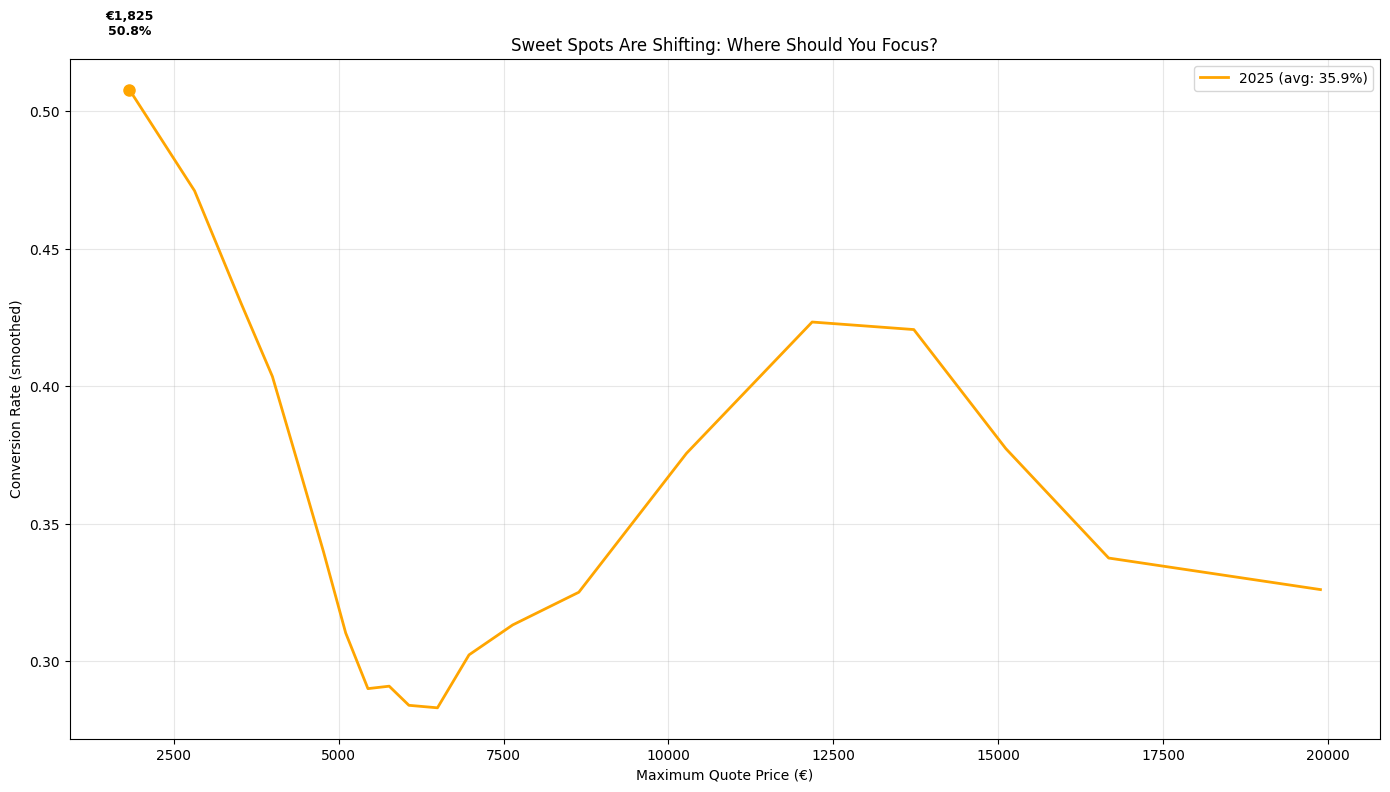


Administrative Uncertainty Effect

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

Decision time distribution:
count    2769.000000
mean        5.037559
std        16.320845
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       145.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 2,389 (86.3%)


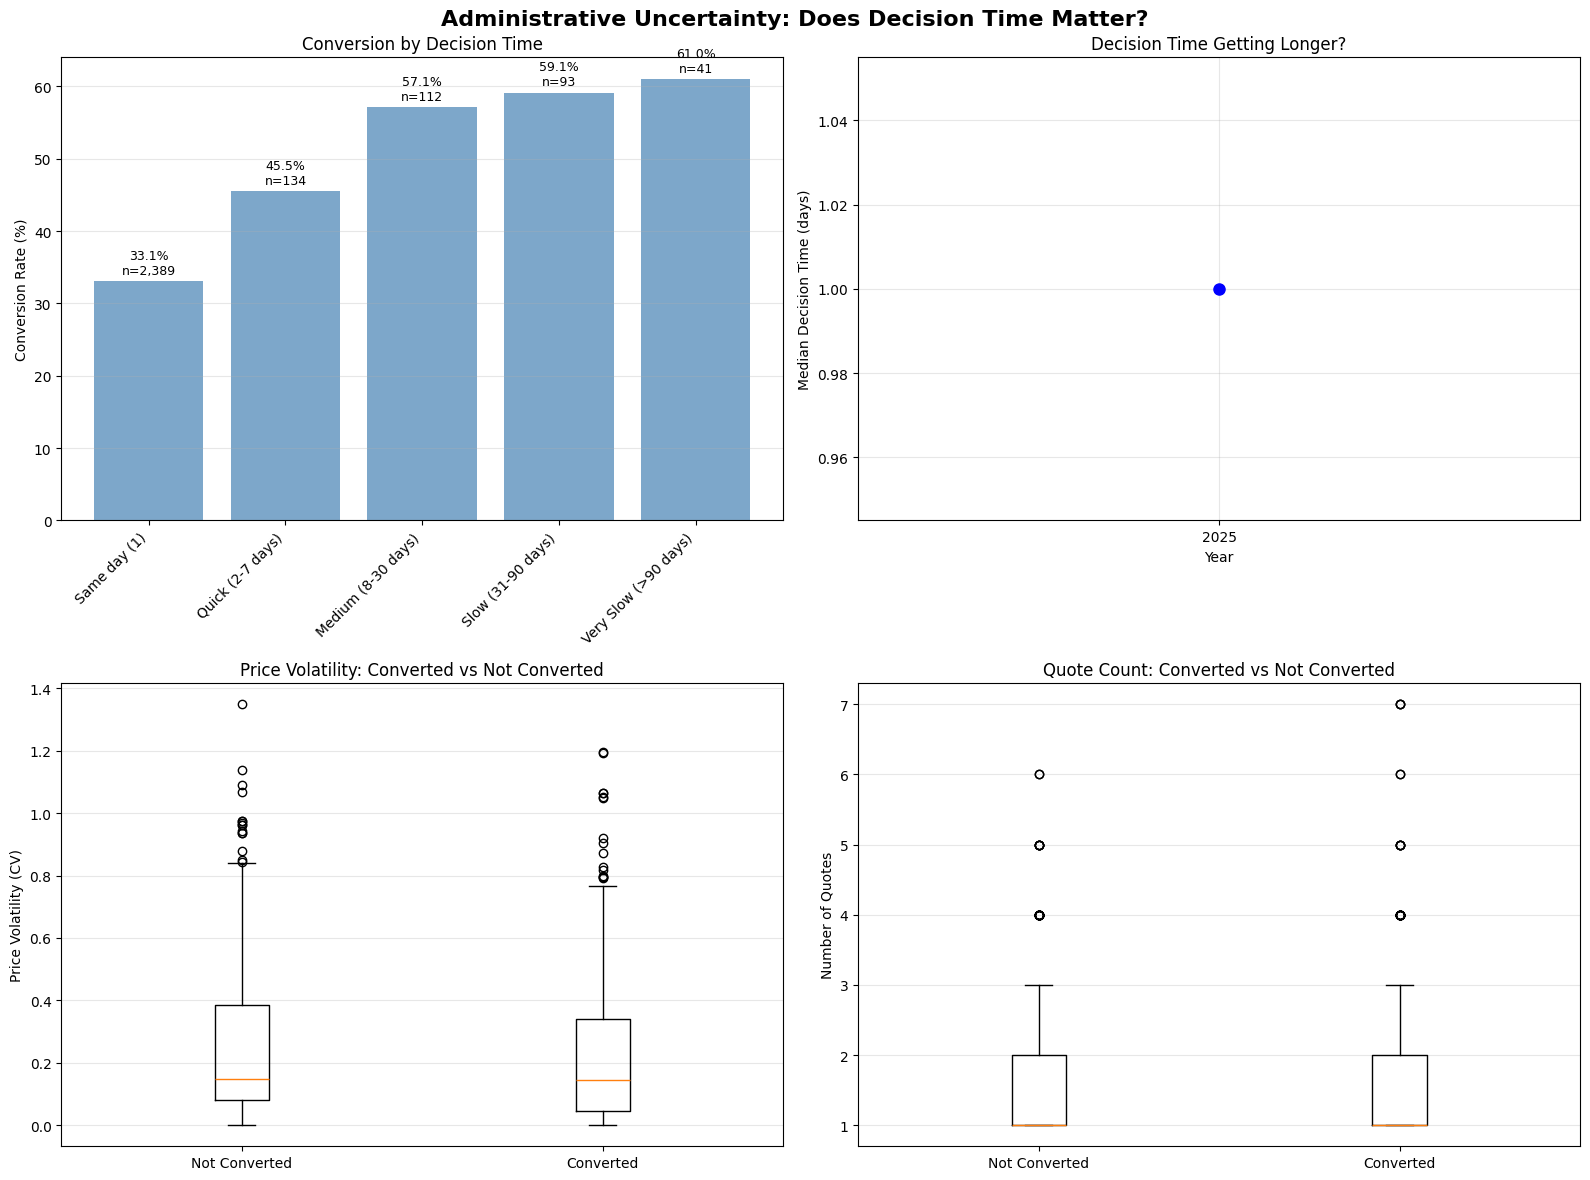


Product Type - Price Conversion Heatmap
Simple pivot table:
price_bin_simple         (1101.459, 4150.254]  (4150.254, 5597.474]  \
main_equipment_category                                               
AC                                  43.750000             27.160494   
Boiler                              51.282051             30.215827   
Heat Pump                            0.000000                   NaN   
Other                               47.647059             31.250000   
Stove                               39.393939             34.736842   

price_bin_simple         (5597.474, 7336.372]  (7336.372, 13193.412]  \
main_equipment_category                                                
AC                                  30.337079              28.767123   
Boiler                              35.714286              35.000000   
Heat Pump                           60.000000              58.088235   
Other                               35.714286              21.739130   
Stove    

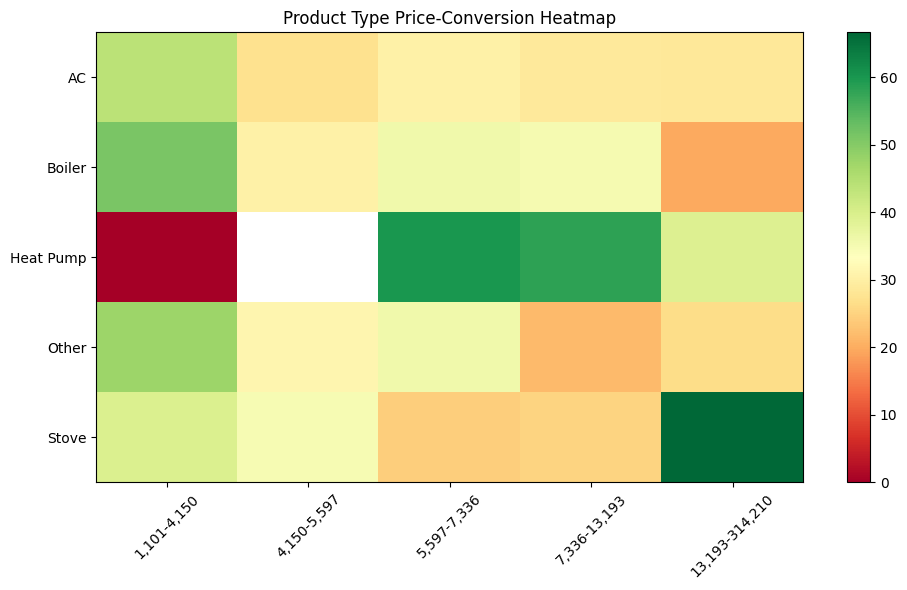


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           926
Poêle                               607
Pompe à chaleur                     523
Climatisation                       495
ECS : Chauffe-eau ou adoucisseur    154
Appareil hybride                     52
Photovoltaïque                       34
Autres                               30
Emetteur de chauffage  ou chappe     25
Produit VMC                          12
Unknown                               9
Accessoire de pose                    4
Plomberie Sanitaire                   1
Name: count, dtype: int64

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263


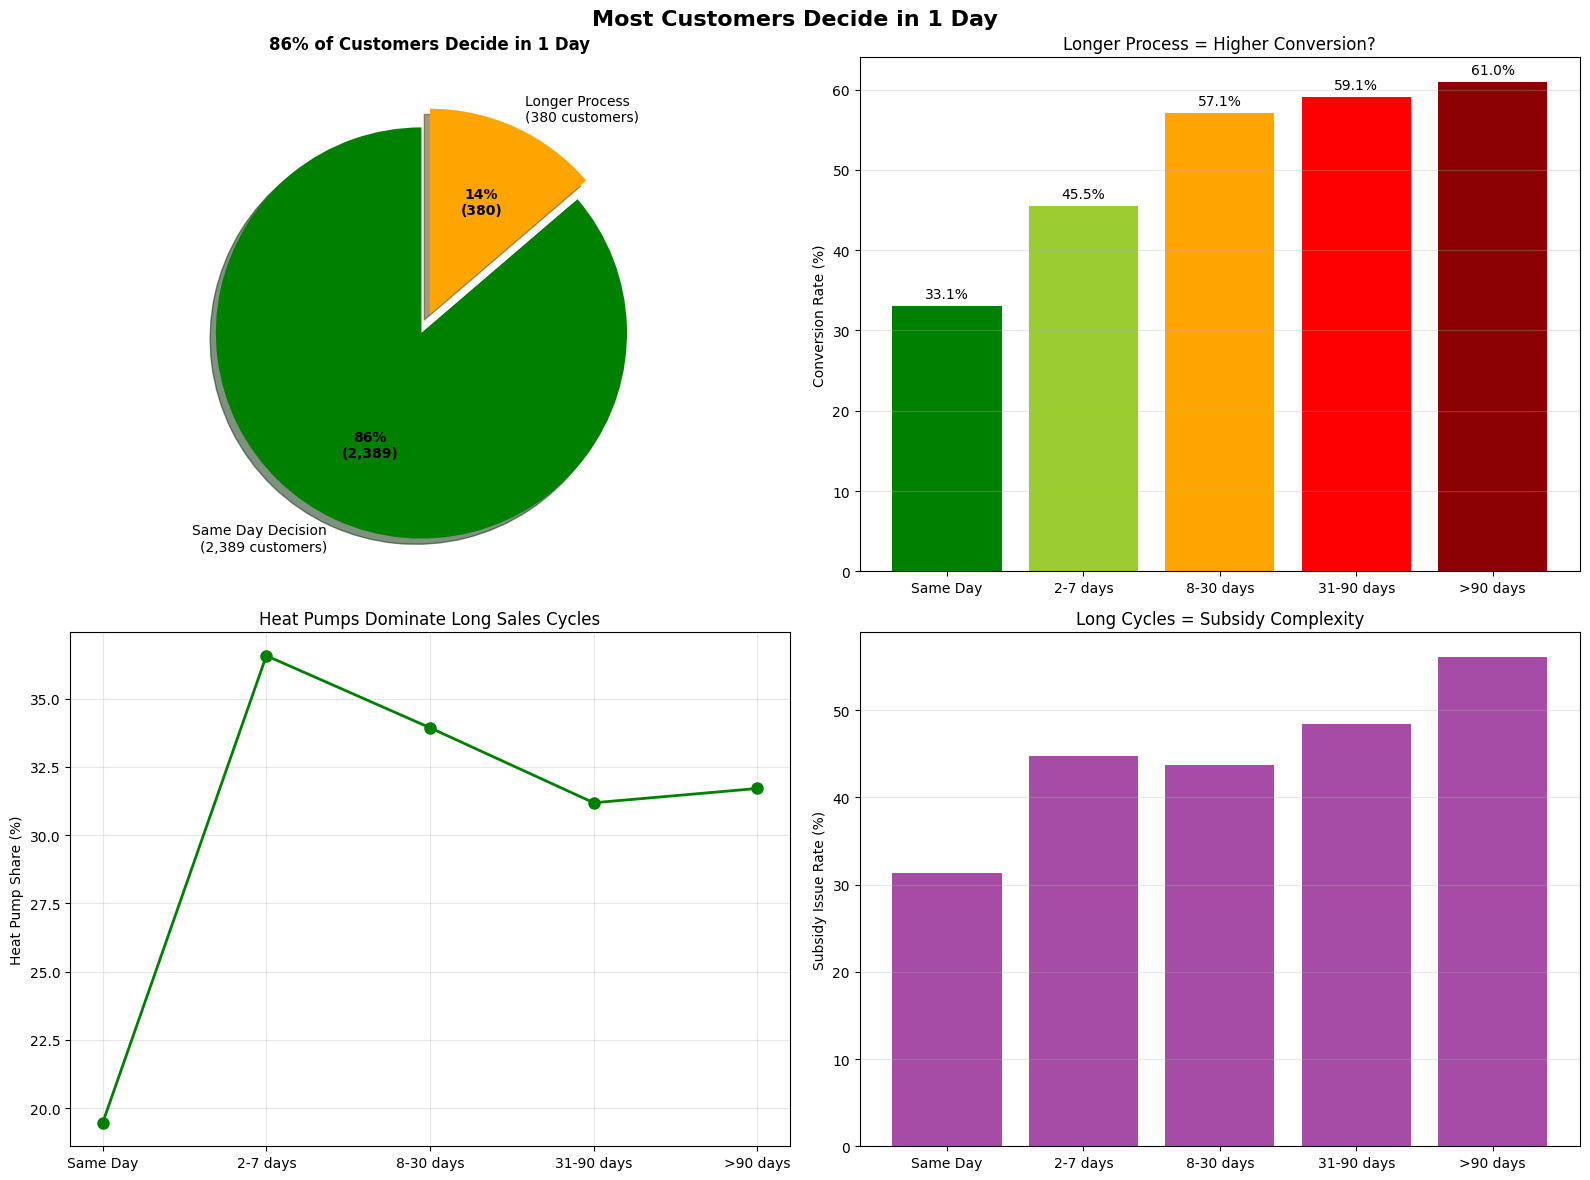


Heat Pump Performance Over Time

Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2025              0.441             594  15056.297               0.869


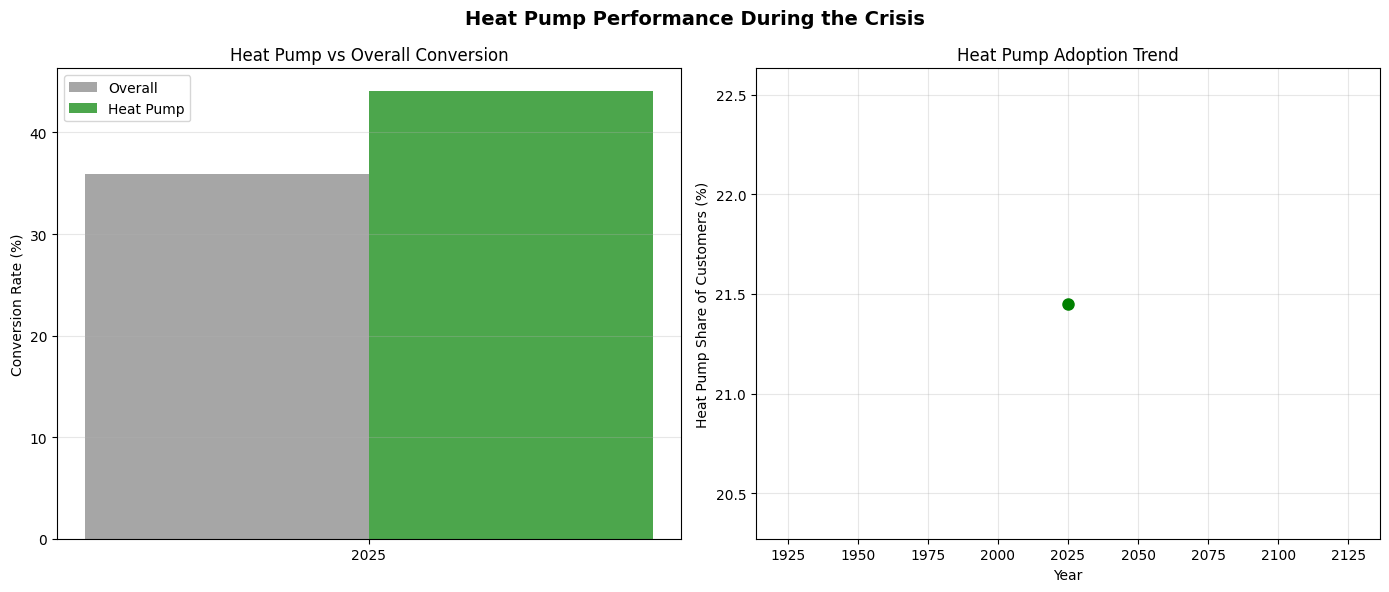


Analyzing 2,769 customers
Price range: €1,343 to €25,821
Median price: €6,263

DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €2.4k (53.3%) and €1.6k (51.6%)
Dead zone: €6.6k-6.9k (23-30%)
Heat pumps: 87% subsidy issues, 44.1% conversion
Price sensitivity: Heat Pump (23.1pts) > Boiler (19.5pts) > AC (15.1pts) > Stove (13.0pts)
Same day decisions: 86%


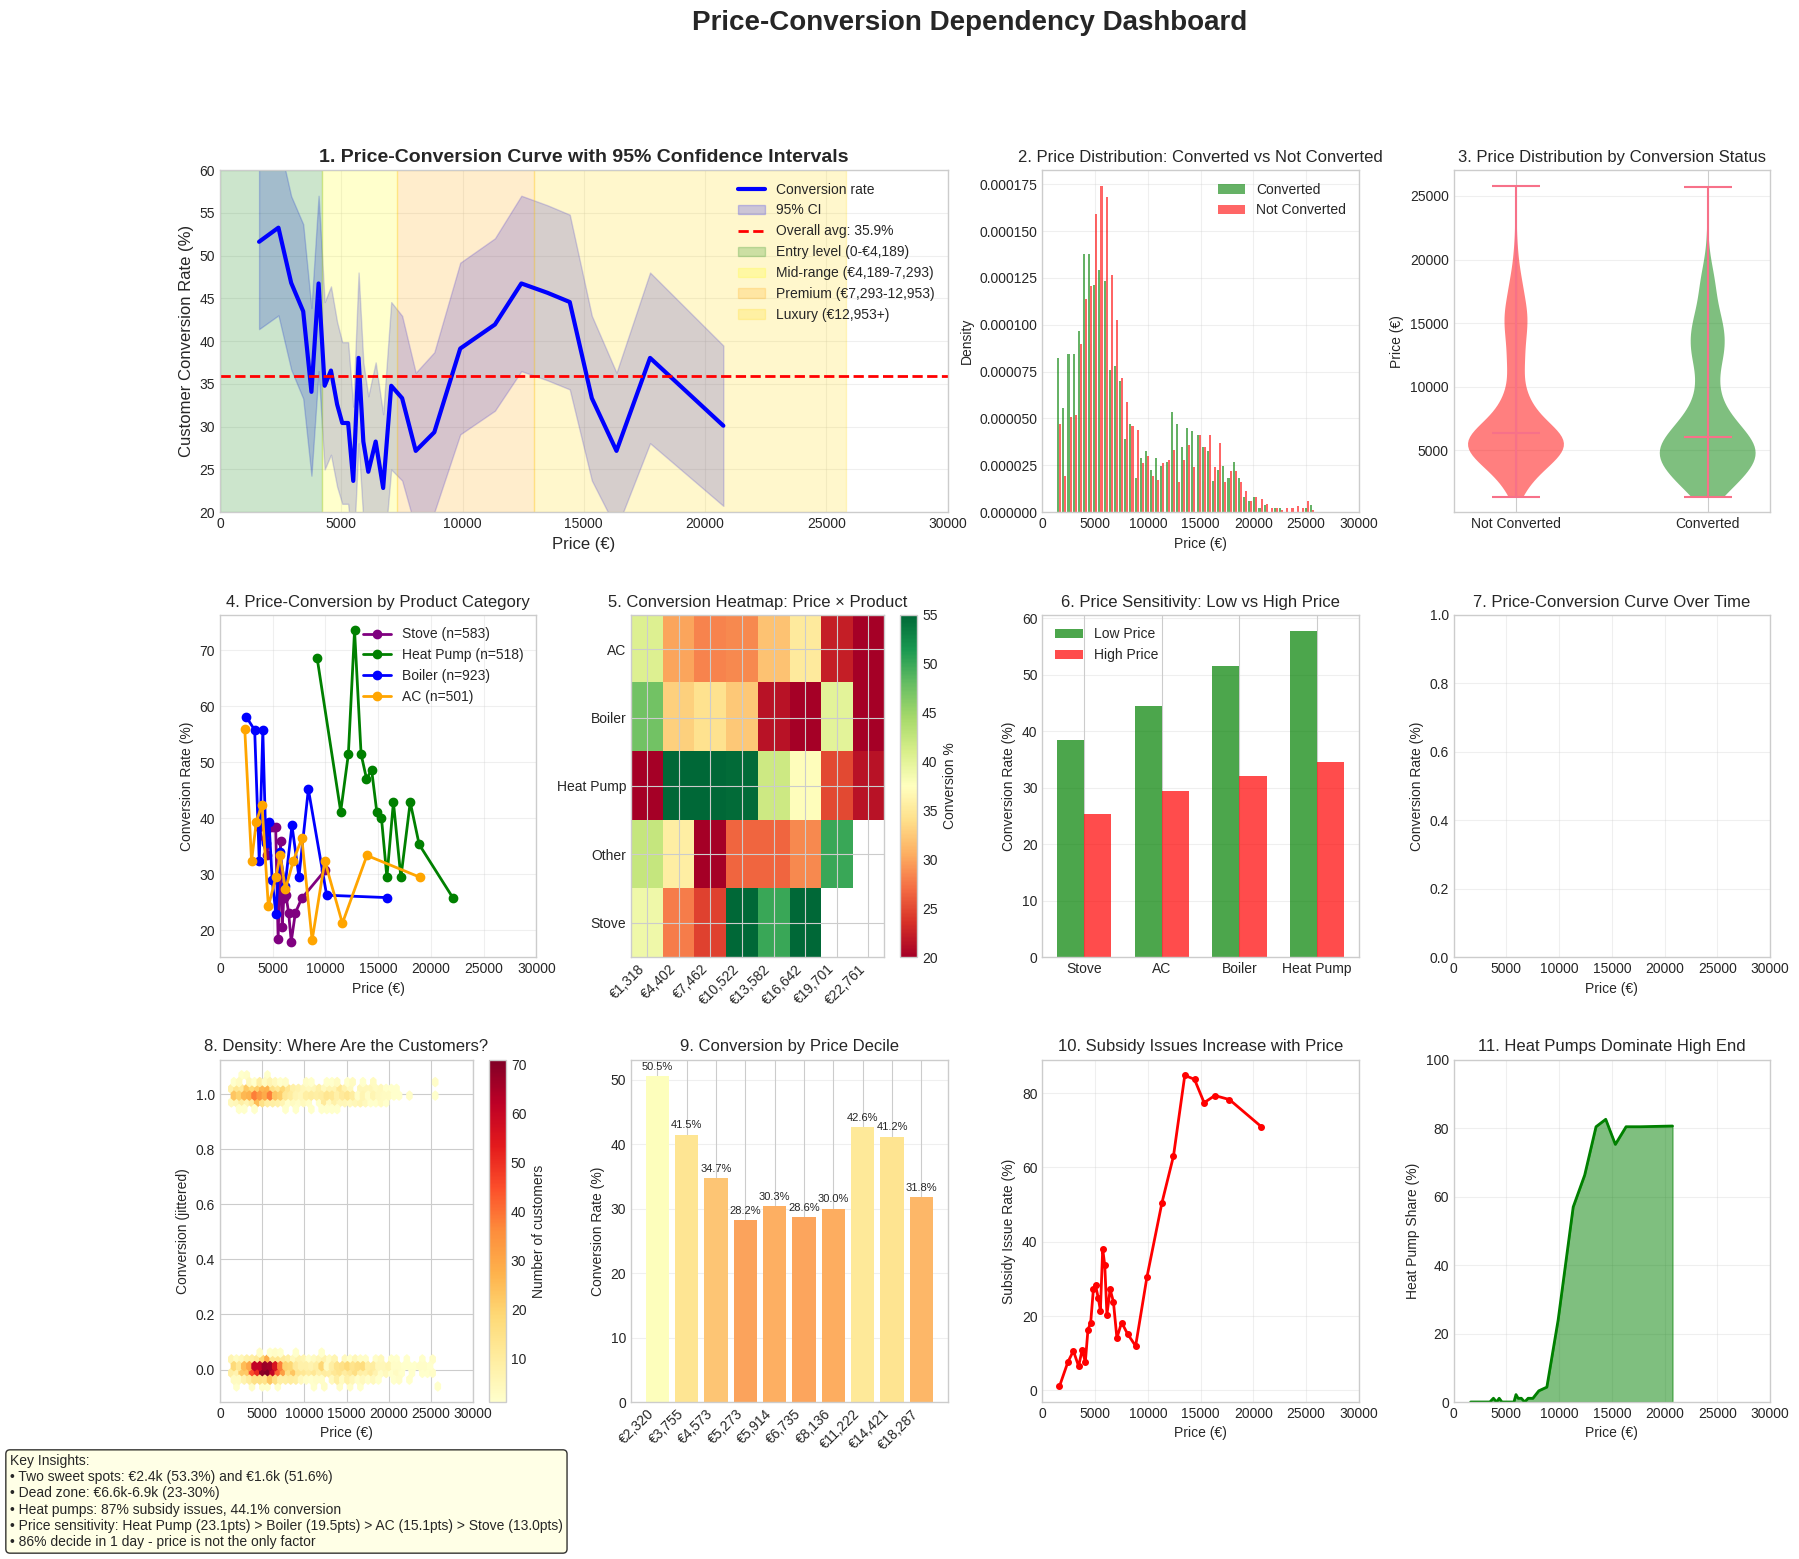

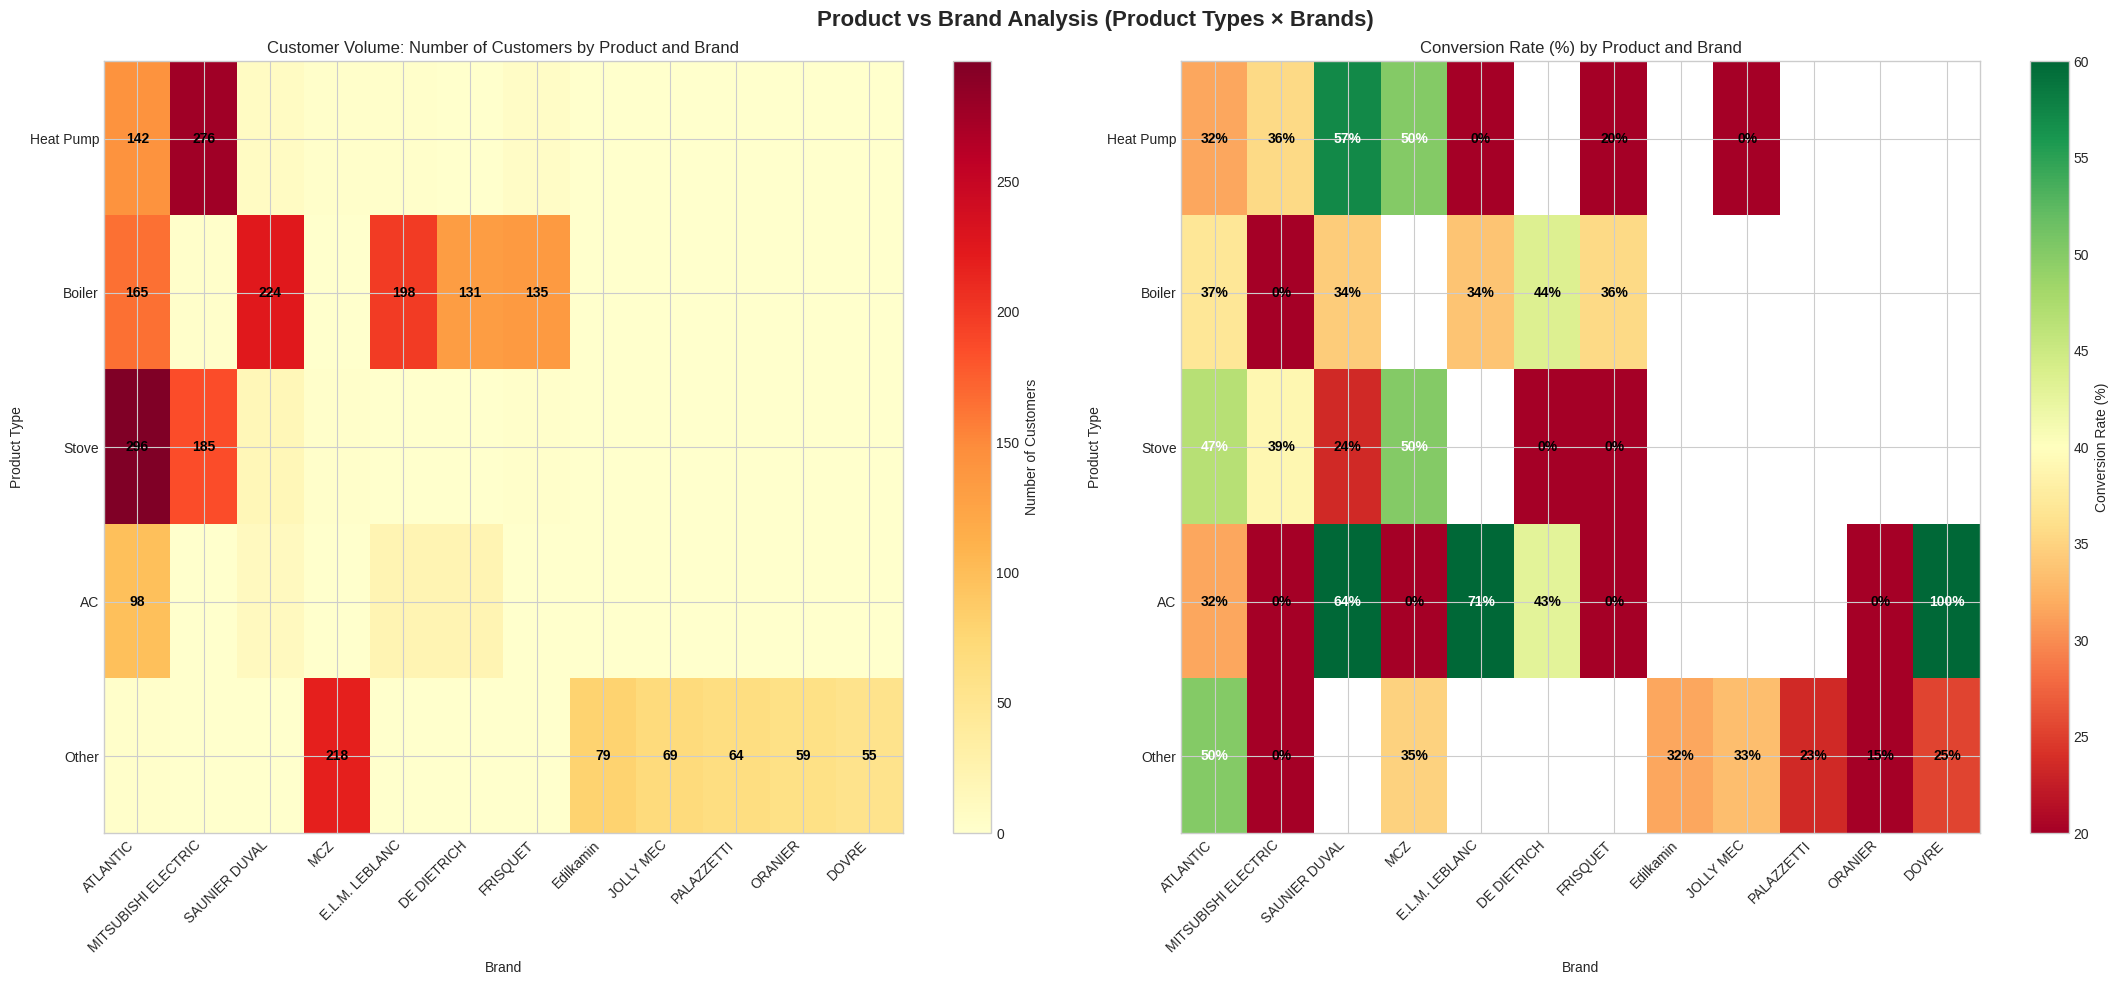


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC  SAUNIER DUVAL  MCZ  E.L.M. LEBLANC  DE DIETRICH  FRISQUET  Edilkamin  JOLLY MEC  PALAZZETTI  ORANIER  DOVRE
main_equipment_category                                                                                                                                            
AC                            142                  276              7    2               2            0         5          0          1           0        0      0
Boiler                        165                    2            224    0             198          131       135          0          0           0        0      0
Heat Pump                     296                  185             17    2               0            1         2          0          0           0        0      0
Other                          

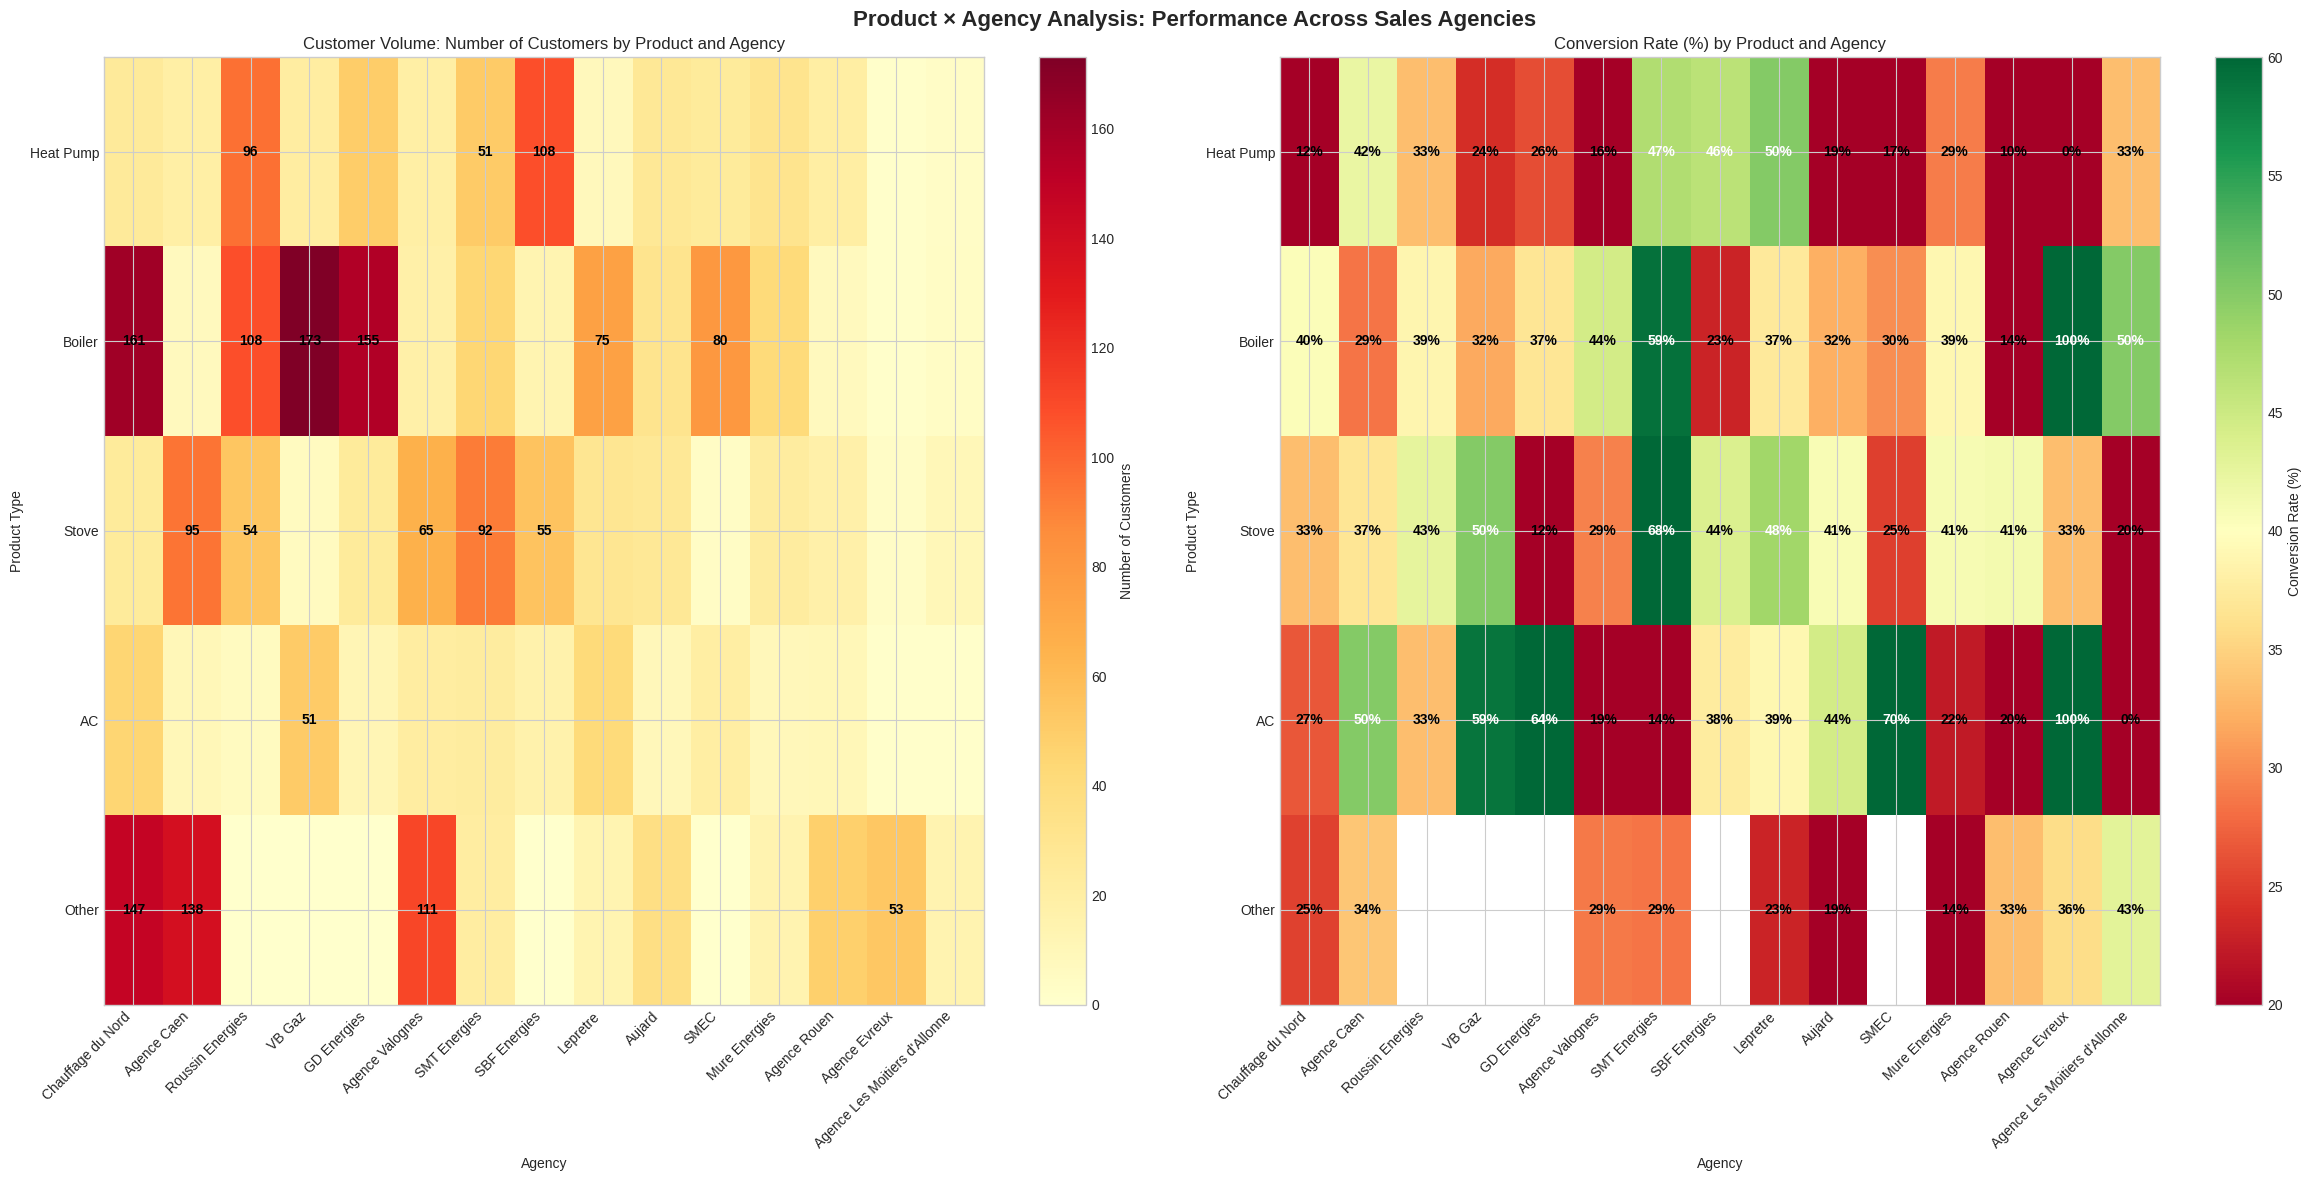


PRODUCT × AGENCY ANALYSIS

📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:
----------------------------------------------------------------------------------------------------
main_agency              Chauffage du Nord  Agence Caen  Roussin Energies  VB Gaz  GD Energies  Agence Valognes  SMT Energies  SBF Energies  Lepretre  Aujard  SMEC  Mure Energies  Agence Rouen  Agence Evreux  Agence Les Moitiers d'Allonne
main_equipment_category                                                                                                                                                                                                                       
AC                                      25           19                96      21           50               19            51           108         8      27    24             31            20              1                              3
Boiler                                 161            7               108     173          155               18  

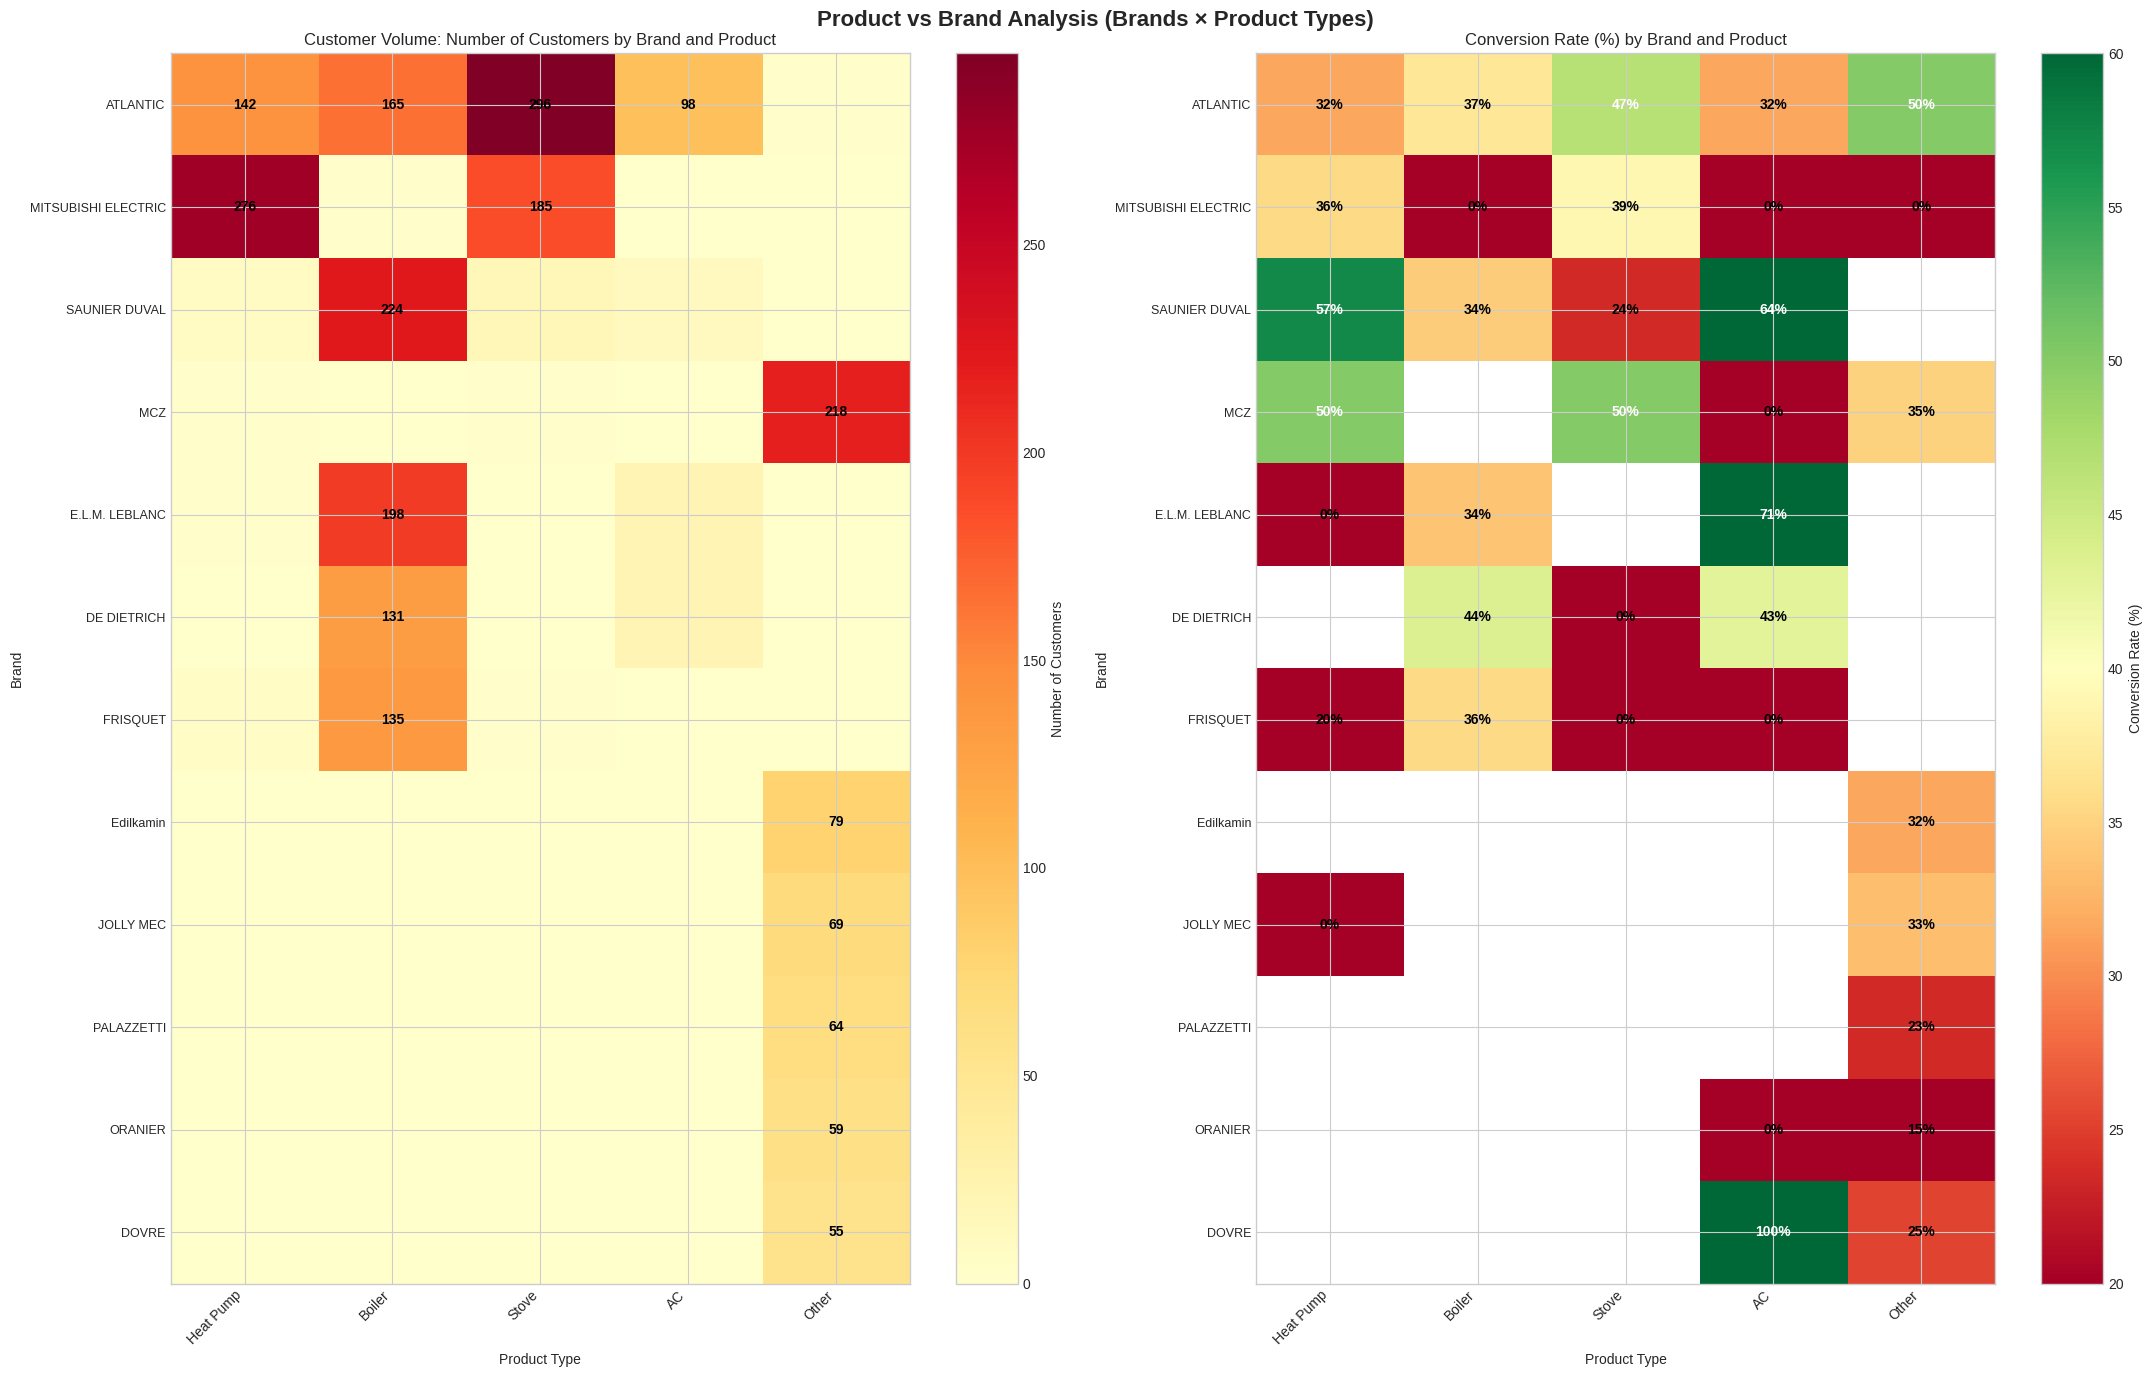


BRAND × PRODUCT ANALYSIS (Swapped Axes)

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_equipment_category   AC  Boiler  Heat Pump  Other  Stove
main_brand                                                   
ATLANTIC                 142     165        296     98      2
MITSUBISHI ELECTRIC      276       2        185      1      1
SAUNIER DUVAL              7     224         17     11      0
MCZ                        2       0          2      1    218
E.L.M. LEBLANC             2     198          0     21      0
DE DIETRICH                0     131          1     21      0
FRISQUET                   5     135          2      1      0
Edilkamin                  0       0          0      0     79
JOLLY MEC                  1       0          0      0     69
PALAZZETTI                 0       0          0      0     64
ORANIER                    0       0          0      1     59
DOVRE                      0  

(main_equipment_category   AC  Boiler  Heat Pump  Other  Stove
 main_brand                                                   
 ATLANTIC                 142     165        296     98      2
 MITSUBISHI ELECTRIC      276       2        185      1      1
 SAUNIER DUVAL              7     224         17     11      0
 MCZ                        2       0          2      1    218
 E.L.M. LEBLANC             2     198          0     21      0
 DE DIETRICH                0     131          1     21      0
 FRISQUET                   5     135          2      1      0
 Edilkamin                  0       0          0      0     79
 JOLLY MEC                  1       0          0      0     69
 PALAZZETTI                 0       0          0      0     64
 ORANIER                    0       0          0      1     59
 DOVRE                      0       0          0      1     55,
 main_equipment_category         AC     Boiler  Heat Pump       Other  \
 main_brand                                 

In [6]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)
visualize_policy_suspension_impact(customers, price_var='max_out_of_pocket')

top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)

visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
show_two_panel_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
visualize_conversion_by_equipment_type_brand_price(customers, price_var='max_out_of_pocket')

visualize_conversion_by_season(customers, price_var='max_out_of_pocket')
visualize_regional_seasonality(customers, price_var='max_out_of_pocket')

visualize_conversion_by_year(customers, price_var='max_out_of_pocket')
report_best_and_worst_months(customers, price_var='max_out_of_pocket')
show_conversion_by_price_over_time(customers, price_var='max_out_of_pocket')
overlay_all_years_on_one_plot(customers, price_var='max_out_of_pocket')
visualize_conversion_by_prices_sweet_spot_shift(customers, price_var='max_out_of_pocket')
visualize_decision_times(customers, price_var='max_out_of_pocket')
show_product_type_price_conversion_heatmap(customers, price_var='max_out_of_pocket')
show_decision_time_dashboard(customers, price_var='max_out_of_pocket')

visualise_heat_pump_performance(customers, price_var='max_out_of_pocket')

show_conversion_by_price_dashboard(customers, price_var='max_out_of_pocket')

show_product_type_by_brand_heatmap(customers)
show_product_type_by_agency_heatmap(customers)
show_brand_by_product_type_heatmap(customers)

In [7]:
import ipynbname
import subprocess
import os
import sys

def export_notebook_to_pdf(overwrite=True, verbose=True):
    """
    Export current notebook to PDF with overwrite control
    
    Args:
        overwrite (bool): If True, overwrite existing PDF file
        verbose (bool): If True, print progress messages
    
    Returns:
        bool: True if successful, False otherwise
    """
    try:
        # Get notebook path
        notebook_path = ipynbname.path()
        notebook_path_str = str(notebook_path)
        pdf_path = notebook_path_str.replace('.ipynb', '.pdf')
        
        if verbose:
            print(f"📓 Notebook: {notebook_path.name}")
            print(f"📄 PDF path: {pdf_path}")
        
        # Check if PDF exists
        if os.path.exists(pdf_path):
            if overwrite:
                if verbose:
                    print(f"🗑️ Removing existing PDF: {pdf_path}")
                os.remove(pdf_path)
            else:
                if verbose:
                    print(f"⚠️ PDF already exists and overwrite=False")
                return False
        
        # Convert to PDF
        if verbose:
            print("🔄 Converting to PDF...")
        
        result = subprocess.run([
            'jupyter', 'nbconvert', '--to', 'pdf',
            '--no-prompt',  # Suppress input prompts
            notebook_path_str
        ], capture_output=True, text=True)
        
        if result.returncode == 0:
            if verbose:
                print(f"✅ PDF saved: {pdf_path}")
            return True
        else:
            if verbose:
                print(f"❌ Conversion failed:")
                print(result.stderr)
            return False
            
    except Exception as e:
        if verbose:
            print(f"❌ Error: {e}")
        return False

# Use the function
if __name__ == "__main__":
    # Overwrite existing PDF
    export_notebook_to_pdf(overwrite=True)
    
    # Or create new version without overwriting
    # export_notebook_to_pdf(overwrite=False)export_full_notebook_to_pdf()

📓 Notebook: _eda_price_2025_Q4.ipynb
📄 PDF path: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025_Q4.pdf
🗑️ Removing existing PDF: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025_Q4.pdf
🔄 Converting to PDF...
✅ PDF saved: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025_Q4.pdf
